# Análisis y Clasificación Inteligente de Tickets de Soporte

**Objetivo:** Sistema de Machine Learning para analizar tickets de soporte que:
- 🎯 Clasifica el tipo de ticket (Incident, Request, Problem)
- 🌍 Detecta automáticamente el idioma (en, es, de, fr, pt)
- 🏢 Determina el nivel de Data Warehouse Snowflake necesario (Basic, Medium, Pro)
- 🗂️ Genera el esquema de base de datos apropiado

**Autor:** Joan Linares  
**Fecha:** Marzo 2026  
**Proyecto:** IceBergTicket - Sistema Inteligente de Tickets

## 1. Importación de Librerías

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
from collections import Counter
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Librerías de preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.base import clone

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Detección de idiomas
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0  # Para resultados consistentes
    LANGDETECT_AVAILABLE = True
except ImportError:
    LANGDETECT_AVAILABLE = False
    print("⚠️  langdetect no disponible. Instalando...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'langdetect'])
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    LANGDETECT_AVAILABLE = True

print("✅ Librerías importadas correctamente")
print(f"✅ Detección de idiomas: {'Disponible' if LANGDETECT_AVAILABLE else 'No disponible'}")

✅ Librerías importadas correctamente
✅ Detección de idiomas: Disponible


## 2. Exploración de Datos (EDA)

En esta sección analizaremos el dataset para comprender su estructura, distribución y características principales.

### 2.1 ETL Pipeline: Carga, Normalización y Unificación de TODOS los Datasets

Los 5 CSVs disponibles tienen **esquemas diferentes**. Este pipeline ETL:
1. **Extract** – Carga los 5 datasets
2. **Transform** – Normaliza todos al formato de `aa_dataset-tickets-multi-lang-5-2-50-version.csv`
3. **Load** – Unifica, limpia duplicados y valida idiomas/tipos

In [2]:
# ============================================================================
# ETL PIPELINE: EXTRACT → TRANSFORM → LOAD
# ============================================================================
# Objetivo: Normalizar los 5 CSVs con diferentes esquemas al formato unificado
# Target: subject, body, answer, type, queue, priority, language, version, tag_1..tag_8
# ============================================================================

data_dir = '../data'

# Esquema objetivo (basado en aa_dataset-tickets-multi-lang-5-2-50-version.csv)
TARGET_COLUMNS = [
    'subject', 'body', 'answer', 'type', 'queue', 'priority',
    'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4',
    'tag_5', 'tag_6', 'tag_7', 'tag_8'
]

# ═══════════════════════════════════════════════════════════════════════════
# FASE 1 — EXTRACT: Carga de todos los datasets
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("FASE 1 — EXTRACT: Carga de todos los datasets")
print("=" * 80 + "\n")

raw_datasets = {}
csv_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    df_temp = pd.read_csv(csv_file)
    raw_datasets[filename] = df_temp

    langs = sorted(df_temp['language'].unique().tolist()) if 'language' in df_temp.columns else ['N/A']
    print(f"📄 {filename}")
    print(f"   Filas: {len(df_temp):>7,}  |  Columnas ({len(df_temp.columns)}): {list(df_temp.columns)}")
    print(f"   Idiomas: {', '.join(map(str, langs))}")
    print()

print(f"✅ {len(raw_datasets)} datasets cargados — Total bruto: {sum(len(d) for d in raw_datasets.values()):,} registros\n")

# ═══════════════════════════════════════════════════════════════════════════
# FASE 2 — TRANSFORM: Normalización de esquemas
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("FASE 2 — TRANSFORM: Normalización al esquema unificado")
print("=" * 80 + "\n")

# ── Función de inferencia de tipo de ticket ─────────────────────────────────

def infer_ticket_type_from_text(text):
    """Infiere Incident / Request / Problem a partir del texto en cualquier idioma."""
    text_lower = str(text).lower()
    
    incident_kw = [
        'error', 'fail', 'crash', 'broken', 'down', 'not working', 'bug',
        'fehler', 'absturz', 'kaputt', 'funktioniert nicht', 'störung', 'ausfall',
        'erreur', 'panne', 'cassé', 'ne fonctionne pas',
        'fallo', 'caído', 'no funciona', 'roto',
        'erro', 'falha', 'quebrado', 'não funciona'
    ]
    problem_kw = [
        'slow', 'performance', 'intermittent', 'recurring', 'root cause',
        'langsam', 'leistung', 'wiederkehrend', 'untersuchen',
        'lent', 'récurrent', 'enquêter',
        'lento', 'rendimiento', 'recurrente', 'investigar',
        'desempenho', 'recorrente'
    ]
    request_kw = [
        'request', 'please', 'need', 'want', 'access', 'install', 'setup', 'new',
        'anfrage', 'bitte', 'brauche', 'zugang', 'installieren', 'einrichten',
        'demande', 'besoin', 'accès', 'installer',
        'solicitud', 'por favor', 'necesito', 'acceso', 'instalar',
        'solicitação', 'preciso', 'acesso'
    ]

    scores = {
        'Incident': sum(1 for kw in incident_kw if kw in text_lower),
        'Problem':  sum(1 for kw in problem_kw  if kw in text_lower),
        'Request':  sum(1 for kw in request_kw  if kw in text_lower),
    }
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Request'   # Default = Request

# ── Normalización por dataset ───────────────────────────────────────────────

def normalize_dataset(df_raw, filename):
    """Normaliza cualquier dataset al esquema TARGET_COLUMNS."""
    df_norm = pd.DataFrame()

    # 1. Copiar columnas que ya existen en el target
    for col in TARGET_COLUMNS:
        df_norm[col] = df_raw[col] if col in df_raw.columns else np.nan

    # 2. Datasets alemanes: no tienen type → inferir del texto
    if 'german_normalized' in filename:
        text_combined = df_raw['subject'].fillna('') + ' ' + df_raw['body'].fillna('')
        df_norm['type'] = text_combined.apply(infer_ticket_type_from_text)
        print(f"  🇩🇪 Tipo inferido para {len(df_norm)} tickets alemanes → {df_norm['type'].value_counts().to_dict()}")

    # 3. multi-lang3-4k: descartar business_type y tag_9
    if 'multi-lang3' in filename:
        extras = [c for c in ('business_type', 'tag_9') if c in df_raw.columns]
        if extras:
            print(f"  🗑️  Columnas extra descartadas: {extras}")

    # 4. Rastrear el origen
    df_norm['_source_file'] = filename

    missing = [c for c in TARGET_COLUMNS if c not in df_raw.columns]
    present = [c for c in TARGET_COLUMNS if c in df_raw.columns]
    print(f"  ✅ {filename}  →  {len(present)}/{len(TARGET_COLUMNS)} columnas preservadas", end='')
    if missing:
        print(f"  |  NaN: {missing}")
    else:
        print()

    return df_norm


normalized_dfs = []
for filename, df_raw in raw_datasets.items():
    df_norm = normalize_dataset(df_raw, filename)
    normalized_dfs.append(df_norm)

print()

# ═══════════════════════════════════════════════════════════════════════════
# FASE 3 — LOAD: Unificación y Limpieza
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("FASE 3 — LOAD: Unificación y Limpieza")
print("=" * 80 + "\n")

# Concatenar todo
df = pd.concat(normalized_dfs, ignore_index=True)
print(f"📊 Dataset unificado bruto: {len(df):,} filas × {len(df.columns)} columnas")

# ── 1. Eliminar duplicados exactos (sobre las columnas target) ──────────
n_before = len(df)
df = df.drop_duplicates(subset=TARGET_COLUMNS, keep='first').reset_index(drop=True)
n_dupes = n_before - len(df)
print(f"🧹 Duplicados eliminados: {n_dupes:,}")

# ── 2. Validar y corregir idiomas ───────────────────────────────────────
VALID_LANGUAGES = {'en', 'es', 'de', 'fr', 'pt'}
print(f"\n🌍 Idiomas antes de limpieza: {sorted(df['language'].dropna().unique().tolist())}")

invalid_lang_mask = ~df['language'].isin(VALID_LANGUAGES) | df['language'].isna()
n_invalid_lang = invalid_lang_mask.sum()

if n_invalid_lang > 0 and LANGDETECT_AVAILABLE:
    print(f"🔍 Detectando idioma para {n_invalid_lang} filas sin idioma válido...")
    text_detect = df.loc[invalid_lang_mask, 'subject'].fillna('') + ' ' + \
                  df.loc[invalid_lang_mask, 'body'].fillna('')

    def safe_detect(text):
        try:
            if pd.isna(text) or str(text).strip() == '':
                return 'en'
            lang = detect(str(text))
            return lang if lang in VALID_LANGUAGES else 'en'
        except Exception:
            return 'en'

    df.loc[invalid_lang_mask, 'language'] = text_detect.apply(safe_detect)

print(f"🌍 Idiomas después de limpieza: {sorted(df['language'].dropna().unique().tolist())}")

# ── 3. Validar y corregir tipos de ticket ────────────────────────────────
VALID_TYPES = {'Incident', 'Request', 'Problem'}
invalid_type_mask = ~df['type'].isin(VALID_TYPES) | df['type'].isna()
n_invalid_type = invalid_type_mask.sum()

if n_invalid_type > 0:
    text_type = df.loc[invalid_type_mask, 'subject'].fillna('') + ' ' + \
                df.loc[invalid_type_mask, 'body'].fillna('')
    df.loc[invalid_type_mask, 'type'] = text_type.apply(infer_ticket_type_from_text)
    print(f"📋 Tipo inferido para {n_invalid_type} filas sin tipo válido")

# ── 4. Eliminar filas sin texto ──────────────────────────────────────────
empty_mask = (df['subject'].fillna('').str.strip() == '') & \
             (df['body'].fillna('').str.strip() == '')
n_empty = empty_mask.sum()
if n_empty > 0:
    df = df[~empty_mask].reset_index(drop=True)
    print(f"🧹 Filas sin texto eliminadas: {n_empty}")

# ═══════════════════════════════════════════════════════════════════════════
# RESUMEN ETL
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("RESUMEN ETL COMPLETO")
print("=" * 80 + "\n")

print(f"📊 Dataset unificado final: {len(df):,} filas × {df.shape[1]} columnas\n")

# Desglose por fuente
print("📁 Contribución por dataset fuente:")
for source, cnt in df['_source_file'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"   {source}: {cnt:,} registros ({pct:.1f}%)")

print(f"\n🌍 Distribución de idiomas:")
for lang, cnt in df['language'].value_counts().sort_index().items():
    pct = cnt / len(df) * 100
    print(f"   {lang}: {cnt:,} ({pct:.1f}%)")

print(f"\n📋 Distribución de tipos:")
for tipo, cnt in df['type'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"   {tipo}: {cnt:,} ({pct:.1f}%)")

# Guardar la columna fuente y eliminarla del df principal
df_sources = df['_source_file'].copy()
df = df.drop(columns=['_source_file'])

print(f"\n✅ ETL completado correctamente.")
print(f"🔍 Dimensiones finales: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📝 Columnas: {list(df.columns)}\n")

df.head()

FASE 1 — EXTRACT: Carga de todos los datasets

📄 aa_dataset-tickets-multi-lang-5-2-50-version.csv
   Filas:  28,587  |  Columnas (16): ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
   Idiomas: de, en

📄 dataset-tickets-german_normalized.csv
   Filas:   2,125  |  Columnas (5): ['subject', 'body', 'queue', 'priority', 'language']
   Idiomas: de

📄 dataset-tickets-german_normalized_50_5_2.csv
   Filas:  13,178  |  Columnas (5): ['subject', 'body', 'queue', 'priority', 'language']
   Idiomas: de

📄 dataset-tickets-multi-lang-4-20k.csv
   Filas:  20,000  |  Columnas (15): ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
   Idiomas: de, en

📄 dataset-tickets-multi-lang3-4k.csv
   Filas:   4,000  |  Columnas (17): ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'business_

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


### 2.2 Información de Variables y Tipos de Datos

In [3]:
# Información detallada del dataset
print("\n" + "="*80)
print("INFORMACIÓN DETALLADA DE LAS VARIABLES")
print("="*80 + "\n")
df.info()

print("\n" + "="*80)
print("VALORES NULOS POR COLUMNA")
print("="*80 + "\n")
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Porcentaje (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_data.to_string(index=False))

print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*80 + "\n")
df.describe(include='all').T


INFORMACIÓN DETALLADA DE LAS VARIABLES

<class 'pandas.DataFrame'>
RangeIndex: 67890 entries, 0 to 67889
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   62124 non-null  str    
 1   body      67887 non-null  str    
 2   answer    52576 non-null  object 
 3   type      67890 non-null  str    
 4   queue     67890 non-null  str    
 5   priority  67890 non-null  str    
 6   language  67890 non-null  str    
 7   version   28587 non-null  float64
 8   tag_1     52587 non-null  object 
 9   tag_2     52528 non-null  object 
 10  tag_3     52356 non-null  object 
 11  tag_4     47989 non-null  object 
 12  tag_5     30999 non-null  object 
 13  tag_6     15406 non-null  object 
 14  tag_7     7013 non-null   object 
 15  tag_8     2741 non-null   object 
dtypes: float64(1), object(9), str(6)
memory usage: 42.1+ MB

VALORES NULOS POR COLUMNA

 Columna  Valores Nulos  Porcentaje (%)
 subject           5766       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject,62124,52200,Synchronisationsproblem,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,67887,59488,Support needed,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,52576,44139,Currently investigating the issue,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,67890,3,Incident,28404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
queue,67890,62,Technical Support,15503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,67890,5,medium,25864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,67890,5,de,36477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
version,28587.0,NaN,NaN,NaN,278.382027,165.962935,51.0,52.0,400.0,400.0,400.0
tag_1,52587,251,Security,9156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tag_2,52528,405,Performance,8698,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretación:**
- El dataset contiene información sobre tickets de soporte con texto (subject, body, answer) y metadatos (type, queue, priority, language, etc.)
- Las variables categóricas incluyen: type, queue, priority, language, version y múltiples tags
- Las variables de texto incluyen: subject, body, answer
- Es importante revisar valores nulos y decidir cómo tratarlos

### 2.3 Distribución de la Variable Objetivo


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: TYPE

    Tipo  Cantidad  Porcentaje (%)
Incident     28404           41.84
 Request     26665           39.28
 Problem     12821           18.88


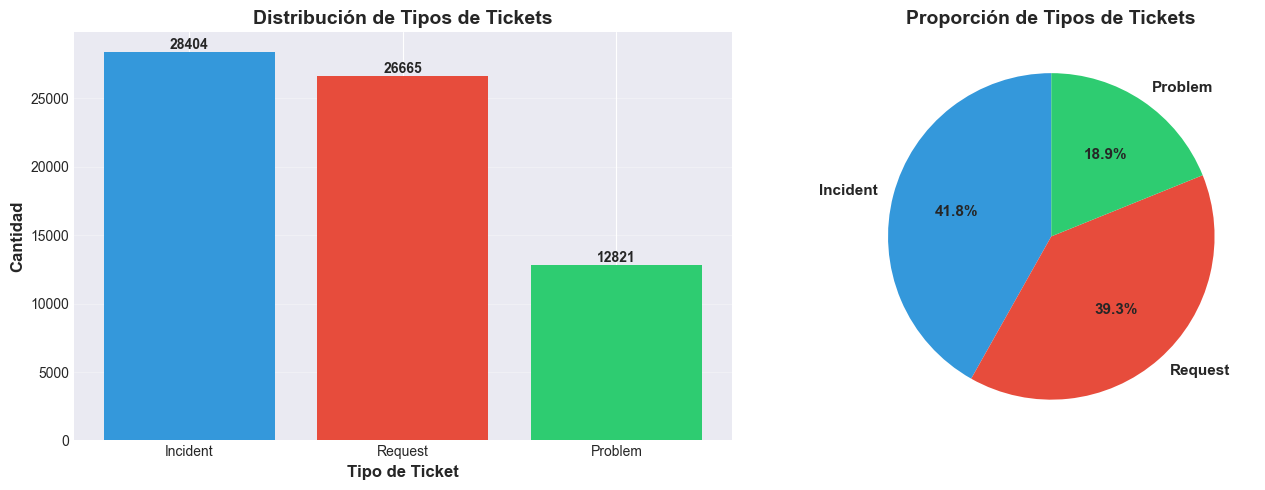

In [4]:
# Análisis de la variable objetivo: 'type'
print("\n" + "="*80)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: TYPE")
print("="*80 + "\n")

type_counts = df['type'].value_counts()
type_percentages = df['type'].value_counts(normalize=True) * 100

type_distribution = pd.DataFrame({
    'Tipo': type_counts.index,
    'Cantidad': type_counts.values,
    'Porcentaje (%)': type_percentages.values.round(2)
})
print(type_distribution.to_string(index=False))

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(type_counts.index, type_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Tipo de Ticket', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Tipos de Tickets', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Tipos de Tickets', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación:**
- La distribución muestra la cantidad de cada tipo de ticket (Incident, Request, Problem)
- Este análisis permite identificar si existe desbalanceo de clases en el dataset

### 2.4 Análisis de Desbalanceo de Clases

In [5]:
# Calcular el ratio de desbalanceo
max_class = type_counts.max()
min_class = type_counts.min()
imbalance_ratio = max_class / min_class

print("\n" + "="*80)
print("ANÁLISIS DE DESBALANCEO DE CLASES")
print("="*80 + "\n")
print(f"📈 Clase mayoritaria: {type_counts.idxmax()} con {max_class} instancias")
print(f"📉 Clase minoritaria: {type_counts.idxmin()} con {min_class} instancias")
print(f"⚖️  Ratio de desbalanceo: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("\n⚠️  ADVERTENCIA: Existe un desbalanceo significativo de clases.")
    print("   Considerar técnicas de balanceo (oversampling, undersampling, SMOTE)")
elif imbalance_ratio > 1.5:
    print("\n⚠️  ATENCIÓN: Existe un desbalanceo moderado de clases.")
else:
    print("\n✓ Las clases están relativamente balanceadas.")


ANÁLISIS DE DESBALANCEO DE CLASES

📈 Clase mayoritaria: Incident con 28404 instancias
📉 Clase minoritaria: Problem con 12821 instancias
⚖️  Ratio de desbalanceo: 2.22:1

⚠️  ATENCIÓN: Existe un desbalanceo moderado de clases.


### 2.5 Análisis de Otras Variables Categóricas

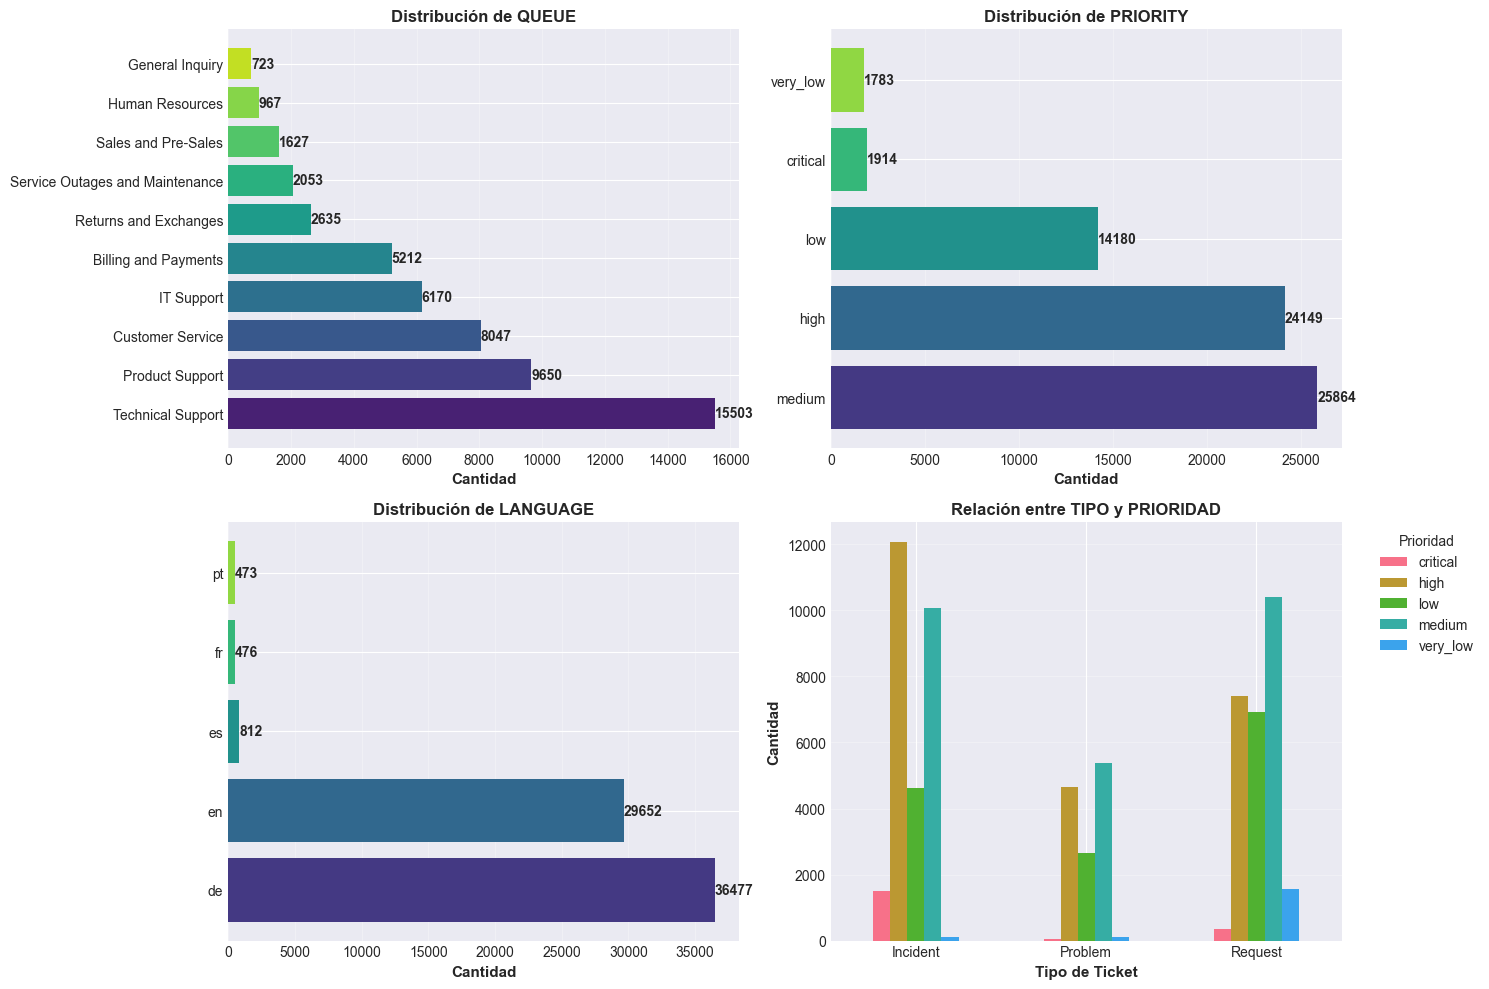

In [6]:
# Distribución de variables categóricas clave
categorical_vars = ['queue', 'priority', 'language']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_vars):
    if col in df.columns:
        counts = df[col].value_counts().head(10)
        axes[idx].barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts)))
        axes[idx].set_xlabel('Cantidad', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Distribución de {col.upper()}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
        # Añadir valores en las barras
        for i, v in enumerate(counts.values):
            axes[idx].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# Relación entre type y priority
if 'priority' in df.columns:
    pd.crosstab(df['type'], df['priority']).plot(kind='bar', ax=axes[3], rot=0)
    axes[3].set_xlabel('Tipo de Ticket', fontsize=11, fontweight='bold')
    axes[3].set_ylabel('Cantidad', fontsize=11, fontweight='bold')
    axes[3].set_title('Relación entre TIPO y PRIORIDAD', fontsize=12, fontweight='bold')
    axes[3].legend(title='Prioridad', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:**
- **Queue:** Muestra las categorías o departamentos más comunes de tickets
- **Priority:** Indica la distribución de prioridades (high, medium, low)
- **Language:** Revela los idiomas predominantes en los tickets
- La relación entre tipo y prioridad ayuda a entender patrones en la clasificación de tickets

### 2.6 Análisis de Variables de Texto

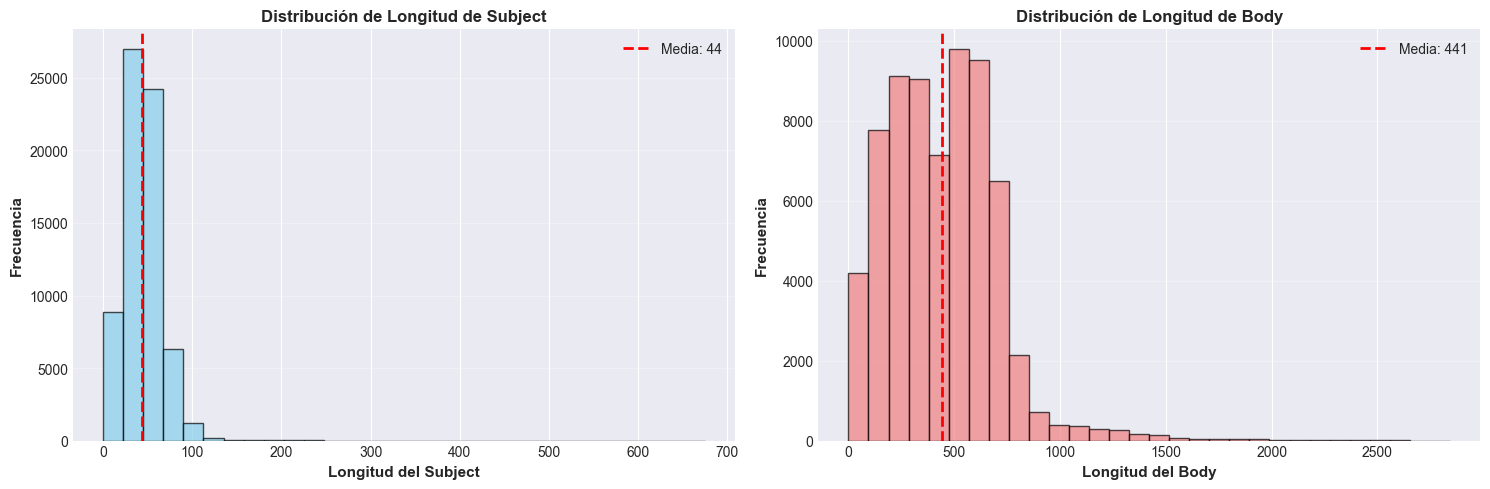


ESTADÍSTICAS DE LONGITUD DE TEXTO

       subject_length   body_length
count    67890.000000  67890.000000
mean        43.513286    441.375460
std         22.849974    259.870875
min          0.000000      0.000000
25%         32.000000    243.000000
50%         43.000000    428.000000
75%         56.000000    602.000000
max        675.000000   2843.000000


In [7]:
# Análisis de longitud de texto
df['subject_length'] = df['subject'].fillna('').astype(str).apply(len)
df['body_length'] = df['body'].fillna('').astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de longitud de subject
axes[0].hist(df['subject_length'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Longitud del Subject', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Longitud de Subject', fontsize=12, fontweight='bold')
axes[0].axvline(df['subject_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["subject_length"].mean():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Histograma de longitud de body
axes[1].hist(df['body_length'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Longitud del Body', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución de Longitud de Body', fontsize=12, fontweight='bold')
axes[1].axvline(df['body_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["body_length"].mean():.0f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ESTADÍSTICAS DE LONGITUD DE TEXTO")
print("="*80 + "\n")
print(df[['subject_length', 'body_length']].describe())

**Interpretación:**
- La longitud del texto (subject y body) varía considerablemente entre tickets
- Esto es relevante para el preprocesamiento de texto y la extracción de características

🔍 Verificando precisión de idiomas etiquetados...
✅ Coincidencia entre idioma etiquetado y detectado: 91.0%

DISTRIBUCIÓN DE IDIOMAS

Idioma  Cantidad  Porcentaje (%)
    de     36477           53.73
    en     29652           43.68
    es       812            1.20
    fr       476            0.70
    pt       473            0.70


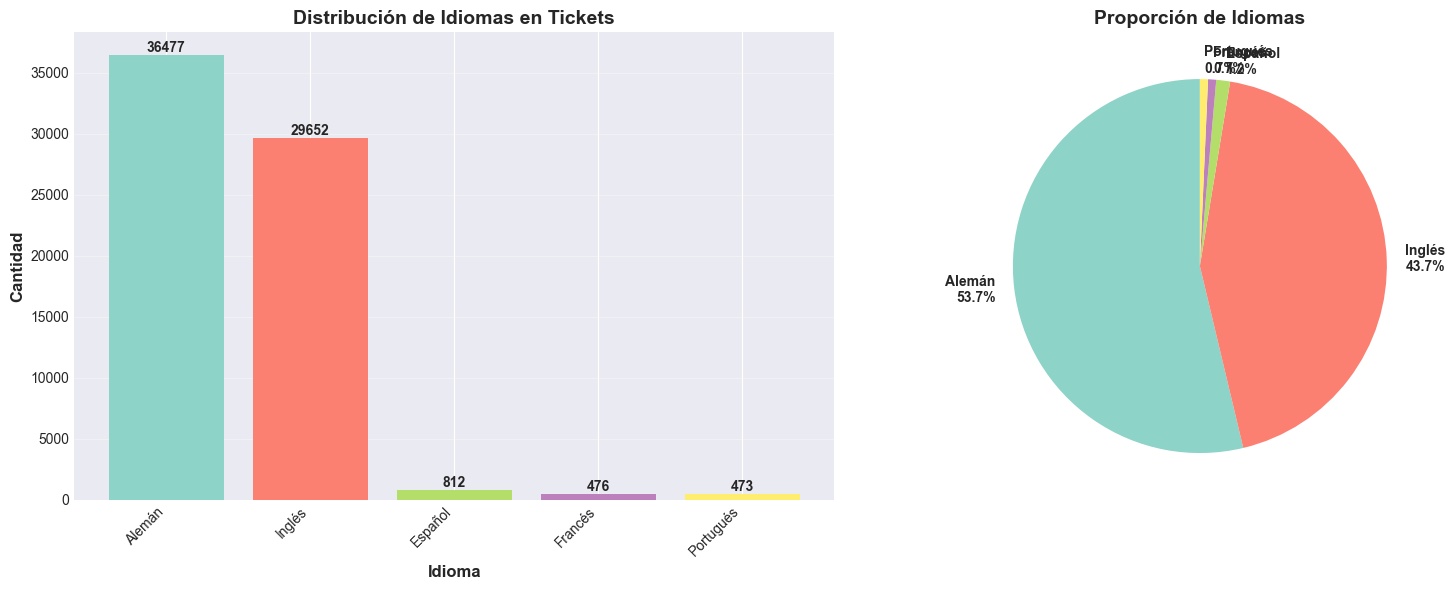


RELACIÓN ENTRE IDIOMA Y TIPO DE TICKET

type      Incident  Problem  Request    All
language                                   
de           15590     5912    14975  36477
en           12121     6486    11045  29652
es             320      186      306    812
fr             182      121      173    476
pt             191      116      166    473
All          28404    12821    26665  67890


<Figure size 1200x600 with 0 Axes>

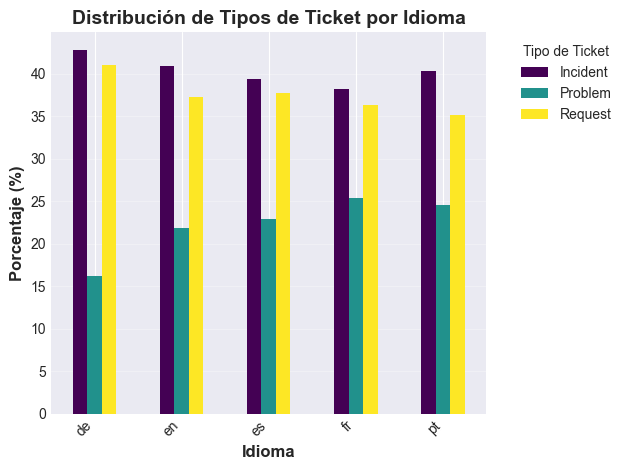

In [8]:
# Función para detectar idioma con manejo de errores
def detect_language(text):
    try:
        if pd.isna(text) or str(text).strip() == '':
            return 'unknown'
        return detect(str(text))
    except:
        return 'unknown'

# Crear texto combinado si no existe
if 'text_combined' not in df.columns:
    df['text_combined'] = (df['subject'].fillna('') + ' ' + df['body'].fillna('')).str.strip()

# Detectar idioma del texto combinado si no hay columna language
if 'language' not in df.columns:
    print("🔍 No hay columna 'language'. Detectando idiomas automáticamente...")
    df['detected_language'] = df['text_combined'].apply(detect_language)
    language_col = 'detected_language'
else:
    language_col = 'language'
    # Verificar si la detección automática coincide con el idioma etiquetado
    print("🔍 Verificando precisión de idiomas etiquetados...")
    sample_size = min(100, len(df))
    sample = df.sample(sample_size, random_state=42)
    sample['detected_lang'] = sample['text_combined'].apply(detect_language)
    
    # Comparar
    matches = (sample[language_col] == sample['detected_lang']).sum()
    accuracy = matches / sample_size * 100
    print(f"✅ Coincidencia entre idioma etiquetado y detectado: {accuracy:.1f}%")

# Análisis de distribución de idiomas
print("\n" + "="*80)
print("DISTRIBUCIÓN DE IDIOMAS")
print("="*80 + "\n")

language_counts = df[language_col].value_counts()
language_percentages = df[language_col].value_counts(normalize=True) * 100

language_dist = pd.DataFrame({
    'Idioma':  language_counts.index,
    'Cantidad': language_counts.values,
    'Porcentaje (%)': language_percentages.values.round(2)
})
print(language_dist.to_string(index=False))

# Mapeo de códigos de idioma a nombres completos
language_names = {
    'en': 'Inglés',
    'es': 'Español',
    'de': 'Alemán',
    'fr': 'Francés',
    'pt': 'Portugués',
    'unknown': 'Desconocido'
}

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
colors_lang = plt.cm.Set3(np.linspace(0, 1, len(language_counts)))
axes[0].bar(range(len(language_counts)), language_counts.values, color=colors_lang)
axes[0].set_xticks(range(len(language_counts)))
axes[0].set_xticklabels([language_names.get(lang, lang) for lang in language_counts.index], 
                        rotation=45, ha='right')
axes[0].set_xlabel('Idioma', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Idiomas en Tickets', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores
for i, v in enumerate(language_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
axes[1].pie(language_counts.values, 
           labels=[f"{language_names.get(lang, lang)}\n{pct:.1f}%" 
                   for lang, pct in zip(language_counts.index, language_percentages.values)],
           colors=colors_lang, autopct='', startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Idiomas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis cruzado: Tipo de ticket por idioma
if 'type' in df.columns:
    print("\n" + "="*80)
    print("RELACIÓN ENTRE IDIOMA Y TIPO DE TICKET")
    print("="*80 + "\n")
    
    cross_tab = pd.crosstab(df[language_col], df['type'], margins=True)
    print(cross_tab)
    
    # Visualización
    cross_tab_pct = pd.crosstab(df[language_col], df['type'], normalize='index') * 100
    
    plt.figure(figsize=(12, 6))
    cross_tab_pct.plot(kind='bar', stacked=False, colormap='viridis')
    plt.xlabel('Idioma', fontsize=12, fontweight='bold')
    plt.ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
    plt.title('Distribución de Tipos de Ticket por Idioma', fontsize=14, fontweight='bold')
    plt.legend(title='Tipo de Ticket', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 2.7 Detección Automática de Idiomas

El sistema debe detectar automáticamente el idioma de los tickets para:
- Clasificar mejor el contenido
- Aplicar procesamiento de texto específico por idioma
- Rutear tickets al equipo de soporte apropiado

### 2.7 Análisis de Tags


📌 Número de columnas de tags: 8

TOP 15 TAGS MÁS FRECUENTES

          Tag  Frecuencia
 Tech Support       24556
           IT       24327
  Performance       20003
     Feedback       14704
          Bug       14064
Documentation       13229
     Security       11801
      Feature       10129
   Disruption        7105
       Outage        6262
    Technical        5806
      Network        5583
      Product        5100
   Resolution        4174
        Sales        3959


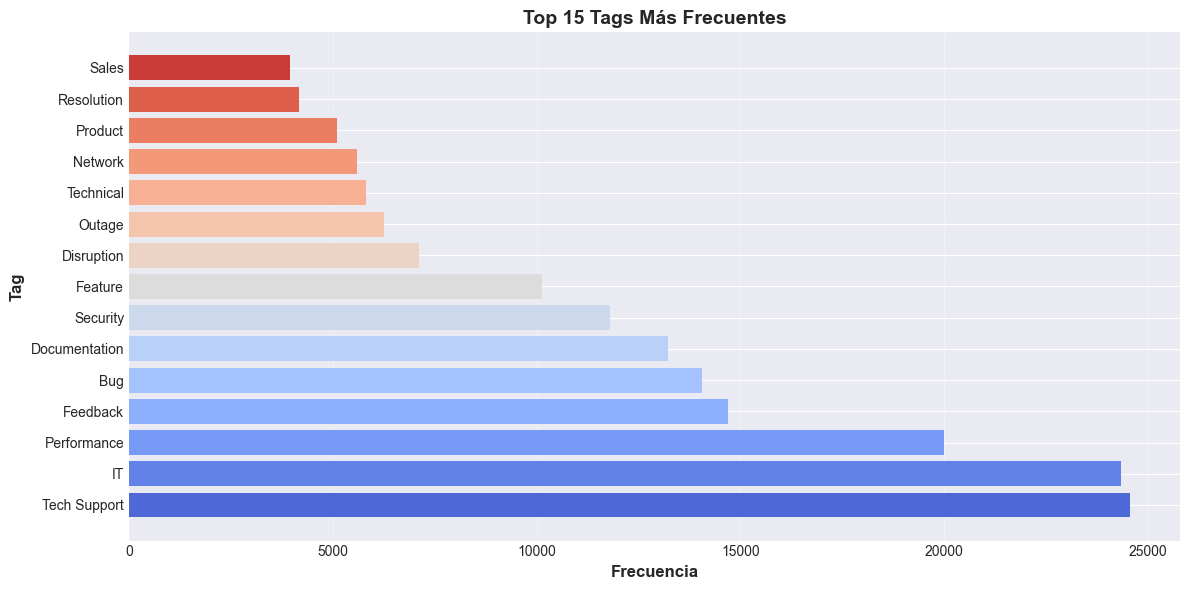

In [9]:
# Análisis de tags
tag_cols = [col for col in df.columns if col.startswith('tag_')]
print(f"\n📌 Número de columnas de tags: {len(tag_cols)}\n")

# Contar tags más frecuentes
all_tags = []
for col in tag_cols:
    all_tags.extend(df[col].dropna().values)

from collections import Counter
tag_counts = Counter(all_tags)
top_tags = pd.DataFrame(tag_counts.most_common(15), columns=['Tag', 'Frecuencia'])

print("="*80)
print("TOP 15 TAGS MÁS FRECUENTES")
print("="*80 + "\n")
print(top_tags.to_string(index=False))

# Visualización
plt.figure(figsize=(12, 6))
plt.barh(top_tags['Tag'], top_tags['Frecuencia'], color=sns.color_palette("coolwarm", len(top_tags)))
plt.xlabel('Frecuencia', fontsize=12, fontweight='bold')
plt.ylabel('Tag', fontsize=12, fontweight='bold')
plt.title('Top 15 Tags Más Frecuentes', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**
- Los tags proporcionan información adicional sobre la naturaleza del ticket
- Los tags más frecuentes pueden ser características importantes para la clasificación

ANÁLISIS DE COMPLEJIDAD DEL DATA WAREHOUSE

🏢 Nivel de Data Warehouse recomendado: MEDIUM
📊 Score de complejidad: 8/15

📝 Descripción: Dataset intermedio con dimensiones adicionales, segmentación y productos

Criterios evaluados:
  1. Número medio de columnas (19)
  2. Alto volumen de datos (67,890 registros)
  3. Múltiples tags (8)
  4. Tiene información de productos

📈 Estadísticas del dataset:
  • Columnas totales: 19
  • Registros: 67,890
  • Tags: 8
  • Productos: Sí
  • Segmentación: No
  • SLAs: No


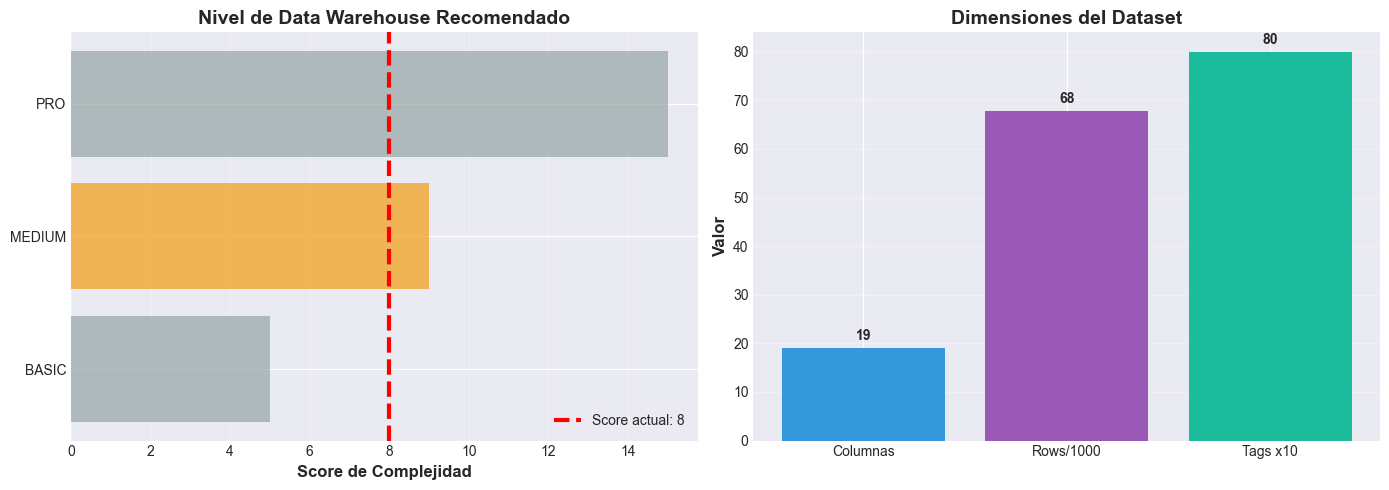


✅ Nivel Snowflake determinado: MEDIUM


In [10]:
# Función para determinar el nivel de complejidad del Data Warehouse necesario
def determine_snowflake_level(dataframe):
    """
    Determina el nivel de Data Warehouse Snowflake necesario basándose en:
    - Número de columnas
    - Complejidad de datos (tags, categorías, productos)
    - Volumen de datos
    - Necesidad de jerarquías y normalizaciones
    """
    
    num_columns = len(dataframe.columns)
    num_rows = len(dataframe)
    
    # Indicadores de complejidad
    has_tags = len([col for col in dataframe.columns if col.startswith('tag_')]) > 0
    num_tags = len([col for col in dataframe.columns if col.startswith('tag_')])
    has_product = 'product' in dataframe.columns or 'version' in dataframe.columns
    has_category = 'category' in dataframe.columns or 'queue' in dataframe.columns
    has_segments = 'segment' in dataframe.columns or 'business_type' in dataframe.columns
    has_sla = any('sla' in col.lower() for col in dataframe.columns)
    
    # Calcular score de complejidad
    complexity_score = 0
    criteria = []
    
    # Criterio 1: Número de columnas
    if num_columns >= 20:
        complexity_score += 3
        criteria.append(f"Alto número de columnas ({num_columns})")
    elif num_columns >= 12:
        complexity_score += 2
        criteria.append(f"Número medio de columnas ({num_columns})")
    else:
        complexity_score += 1
        criteria.append(f"Pocas columnas ({num_columns})")
    
    # Criterio 2: Volumen de datos
    if num_rows >= 50000:
        complexity_score += 3
        criteria.append(f"Alto volumen de datos ({num_rows:,} registros)")
    elif num_rows >= 10000:
        complexity_score += 2
        criteria.append(f"Volumen medio de datos ({num_rows:,} registros)")
    else:
        complexity_score += 1
        criteria.append(f"Bajo volumen de datos ({num_rows:,} registros)")
    
    # Criterio 3: Tags múltiples
    if num_tags >= 5:
        complexity_score += 2
        criteria.append(f"Múltiples tags ({num_tags})")
    elif num_tags > 0:
        complexity_score += 1
        criteria.append(f"Algunos tags ({num_tags})")
    
    # Criterio 4: Dimensiones adicionales
    if has_product:
        complexity_score += 1
        criteria.append("Tiene información de productos")
    
    if has_segments:
        complexity_score += 1
        criteria.append("Tiene segmentación de clientes")
    
    if has_sla:
        complexity_score += 1
        criteria.append("Tiene información de SLAs")
    
    # Determinar nivel basándose en el score
    if complexity_score >= 10:
        level = "PRO"
        description = "Dataset complejo que requiere normalización avanzada, jerarquías y múltiples tablas bridge"
    elif complexity_score >= 6:
        level = "MEDIUM"
        description = "Dataset intermedio con dimensiones adicionales, segmentación y productos"
    else:
        level = "BASIC"
        description = "Dataset simple con dimensiones esenciales para comenzar"
    
    return {
        'level': level,
        'score': complexity_score,
        'description': description,
        'criteria': criteria,
        'stats': {
            'columns': num_columns,
            'rows': num_rows,
            'tags': num_tags,
            'has_product': has_product,
            'has_segments': has_segments,
            'has_sla': has_sla
        }
    }

# Analizar el dataset actual
print("=" * 80)
print("ANÁLISIS DE COMPLEJIDAD DEL DATA WAREHOUSE")
print("=" * 80 + "\n")

dw_analysis = determine_snowflake_level(df)

print(f"🏢 Nivel de Data Warehouse recomendado: {dw_analysis['level']}")
print(f"📊 Score de complejidad: {dw_analysis['score']}/15")
print(f"\n📝 Descripción: {dw_analysis['description']}\n")

print("Criterios evaluados:")
for i, criterion in enumerate(dw_analysis['criteria'], 1):
    print(f"  {i}. {criterion}")

print(f"\n📈 Estadísticas del dataset:")
print(f"  • Columnas totales: {dw_analysis['stats']['columns']}")
print(f"  • Registros: {dw_analysis['stats']['rows']:,}")
print(f"  • Tags: {dw_analysis['stats']['tags']}")
print(f"  • Productos: {'Sí' if dw_analysis['stats']['has_product'] else 'No'}")
print(f"  • Segmentación: {'Sí' if dw_analysis['stats']['has_segments'] else 'No'}")
print(f"  • SLAs: {'Sí' if dw_analysis['stats']['has_sla'] else 'No'}")

# Visualización del nivel de complejidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Score de complejidad
levels = ['BASIC', 'MEDIUM', 'PRO']
level_colors = ['#2ecc71', '#f39c12', '#e74c3c']
level_scores = [5, 9, 15]  # Scores máximos para cada nivel

current_level_idx = levels.index(dw_analysis['level'])
colors = [level_colors[i] if i == current_level_idx else '#95a5a6' for i in range(3)]

axes[0].barh(levels, level_scores, color=colors, alpha=0.7)
axes[0].axvline(dw_analysis['score'], color='red', linestyle='--', linewidth=3, label=f'Score actual: {dw_analysis["score"]}')
axes[0].set_xlabel('Score de Complejidad', fontsize=12, fontweight='bold')
axes[0].set_title('Nivel de Data Warehouse Recomendado', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Dimensiones del dataset
dimensions = ['Columnas', 'Rows/1000', 'Tags x10']
dim_values = [
    dw_analysis['stats']['columns'],
    dw_analysis['stats']['rows'] / 1000,
    dw_analysis['stats']['tags'] * 10
]

axes[1].bar(dimensions, dim_values, color=['#3498db', '#9b59b6', '#1abc9c'])
axes[1].set_ylabel('Valor', fontsize=12, fontweight='bold')
axes[1].set_title('Dimensiones del Dataset', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir valores
for i, v in enumerate(dim_values):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Guardar el nivel determinado para uso posterior
SNOWFLAKE_LEVEL = dw_analysis['level']
print(f"\n✅ Nivel Snowflake determinado: {SNOWFLAKE_LEVEL}")

### 2.8 Determinación del Nivel de Data Warehouse Snowflake

El sistema analizará la complejidad del dataset para determinar qué nivel de Data Warehouse es necesario:

- **BASIC**: Datasets simples con pocas dimensiones (< 10 columnas, datos básicos)
- **MEDIUM**: Datasets medianos con más dimensiones y relaciones (10-20 columnas, segmentación, productos)
- **PRO**: Datasets complejos con muchas dimensiones normalizadas (> 20 columnas, jerarquías, análisis avanzado)

## 3. Preparación de Datos para Modelos ML

En esta sección prepararemos los datos para entrenar modelos que puedan:
1. Clasificar el tipo de ticket (Incident, Request, Problem)
2. Detectar automáticamente el idioma
3. Determinar el nivel de Data Warehouse necesario

### 3.1 Selección y Creación de Features

In [11]:
# Crear una copia del dataframe
df_ml = df.copy()

# Eliminar valores nulos en las variables objetivo
df_ml = df_ml[df_ml['type'].notna()].reset_index(drop=True)
if language_col in df_ml.columns:
    df_ml = df_ml[df_ml[language_col].notna()].reset_index(drop=True)

print(f"✓ Instancias después de limpieza: {len(df_ml)}")

# Crear texto combinado si no existe
if 'text_combined' not in df_ml.columns:
    df_ml['text_combined'] = (df_ml['subject'].fillna('') + ' ' + df_ml['body'].fillna('')).str.strip()

# Crear features adicionales
df_ml['subject_length'] = df_ml['subject'].fillna('').astype(str).apply(len)
df_ml['body_length'] = df_ml['body'].fillna('').astype(str).apply(len)
df_ml['text_length'] = df_ml['text_combined'].apply(len)
df_ml['word_count'] = df_ml['text_combined'].apply(lambda x: len(str(x).split()))

# ============================================================================
# ASIGNACIÓN DE NIVEL SNOWFLAKE — Distribución: BASIC < MEDIUM < PRO
# ============================================================================
# Se calcula un score de complejidad por ticket y se usan percentiles para
# garantizar que PRO tenga MÁS tickets, MEDIUM intermedio y BASIC menos.
# ============================================================================

def calculate_complexity_score(row):
    """Score numérico de complejidad (0-13) que captura múltiples dimensiones."""
    score = 0

    # Longitud de texto (0-3 pts)
    text_len = row.get('text_length', 0)
    if text_len > 2000:
        score += 3
    elif text_len > 1000:
        score += 2
    elif text_len > 500:
        score += 1

    # Cantidad de tags no nulos (0-3 pts)
    n_tags = sum(1 for col in row.index if col.startswith('tag_') and pd.notna(row[col]))
    score += min(n_tags, 3)

    # Tiene respuesta (answer) (0-1 pts)
    if pd.notna(row.get('answer', None)) and str(row.get('answer', '')).strip() != '':
        score += 1

    # Tiene versión (0-1 pts)
    if pd.notna(row.get('version', None)):
        score += 1

    # Prioridad alta (0-1 pts)
    if str(row.get('priority', '')).lower() == 'high':
        score += 1

    # Tipo complejo: Incident o Problem (0-1 pts)
    if row.get('type', '') in ('Incident', 'Problem'):
        score += 1

    # Recuento de palabras (0-2 pts)
    wc = row.get('word_count', 0)
    if wc > 200:
        score += 2
    elif wc > 100:
        score += 1

    return score


# Calcular score para cada ticket
df_ml['complexity_score'] = df_ml.apply(calculate_complexity_score, axis=1)

# Usar percentiles para garantizar BASIC < MEDIUM < PRO
# Target: ~20% BASIC, ~30% MEDIUM, ~50% PRO
ranks = df_ml['complexity_score'].rank(method='first', pct=True)
df_ml['snowflake_level'] = pd.cut(
    ranks,
    bins=[0, 0.20, 0.50, 1.0],
    labels=['BASIC', 'MEDIUM', 'PRO'],
    include_lowest=True
)

# Mostrar distribución de niveles Snowflake
print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE NIVELES SNOWFLAKE (Por Ticket)")
print("=" * 80 + "\n")

level_counts = df_ml['snowflake_level'].value_counts()
for lvl in ['BASIC', 'MEDIUM', 'PRO']:
    cnt = level_counts.get(lvl, 0)
    pct = cnt / len(df_ml) * 100
    icon = {'BASIC': '🟢', 'MEDIUM': '🟡', 'PRO': '🔴'}[lvl]
    bar = '█' * int(pct / 2)
    print(f"  {icon} {lvl:>6}: {cnt:>7,} tickets ({pct:>5.1f}%)  {bar}")

print(f"\n  📊 Score de complejidad → min={df_ml['complexity_score'].min()}, "
      f"media={df_ml['complexity_score'].mean():.1f}, max={df_ml['complexity_score'].max()}")

# Verificar que se cumple BASIC < MEDIUM < PRO
b, m, p = level_counts.get('BASIC', 0), level_counts.get('MEDIUM', 0), level_counts.get('PRO', 0)
assert b < m < p, f"❌ Distribución no cumple BASIC < MEDIUM < PRO: {b} < {m} < {p}"
print(f"\n  ✅ Verificado: BASIC ({b:,}) < MEDIUM ({m:,}) < PRO ({p:,})")

# Rellenar valores nulos en variables categóricas
categorical_features = ['queue', 'priority', language_col]
for col in categorical_features:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna('unknown')

print(f"\n✓ Features categóricas preparadas: {categorical_features}")
print(f"✓ Feature de texto creada: text_combined")
print(f"✓ Variables objetivo:")
print(f"  - Tipo de ticket (type)")
print(f"  - Idioma ({language_col})")
print(f"  - Nivel Snowflake (snowflake_level)")

✓ Instancias después de limpieza: 67890

DISTRIBUCIÓN DE NIVELES SNOWFLAKE (Por Ticket)

  🟢  BASIC:  13,578 tickets ( 20.0%)  ██████████
  🟡 MEDIUM:  20,367 tickets ( 30.0%)  ███████████████
  🔴    PRO:  33,945 tickets ( 50.0%)  █████████████████████████

  📊 Score de complejidad → min=0, media=5.1, max=11

  ✅ Verificado: BASIC (13,578) < MEDIUM (20,367) < PRO (33,945)

✓ Features categóricas preparadas: ['queue', 'priority', 'language']
✓ Feature de texto creada: text_combined
✓ Variables objetivo:
  - Tipo de ticket (type)
  - Idioma (language)
  - Nivel Snowflake (snowflake_level)


### 3.1.1 División Estratégica de Datos por Esquema Snowflake

Una vez asignado el nivel Snowflake a cada ticket, realizamos una **división estratégica** de los datos en 3 subconjuntos:

- **BASIC**: Tickets simples → esquema con dimensiones esenciales (5-6 tablas)
- **MEDIUM**: Tickets de complejidad intermedia → esquema con segmentación y productos (~15 tablas)
- **PRO**: Tickets complejos → esquema normalizado con jerarquías y bridge tables (~25 tablas)

Esta división permite:
1. Perfilar las características reales de cada grupo
2. Generar esquemas SQL adaptados al perfil de datos real
3. Diseñar ETL específicos por nivel de complejidad
4. Dimensionar correctamente cada Data Warehouse

In [12]:
# ============================================================================
# DIVISIÓN ESTRATÉGICA DE DATOS POR ESQUEMA SNOWFLAKE
# ============================================================================

# Separar datos en 3 subconjuntos estratégicos
df_basic = df_ml[df_ml['snowflake_level'] == 'BASIC'].copy()
df_medium = df_ml[df_ml['snowflake_level'] == 'MEDIUM'].copy()
df_pro = df_ml[df_ml['snowflake_level'] == 'PRO'].copy()

print("=" * 80)
print("DIVISIÓN ESTRATÉGICA DE DATOS POR ESQUEMA SNOWFLAKE")
print("=" * 80 + "\n")

total = len(df_ml)
for name, subset in [('BASIC', df_basic), ('MEDIUM', df_medium), ('PRO', df_pro)]:
    pct = len(subset) / total * 100
    icon = {'BASIC': '🟢', 'MEDIUM': '🟡', 'PRO': '🔴'}[name]
    print(f"{icon} {name}: {len(subset):,} tickets ({pct:.1f}%)")

# ============================================================================
# PERFIL DETALLADO DE CADA GRUPO
# ============================================================================

print("\n" + "=" * 80)
print("PERFIL DETALLADO POR ESQUEMA")
print("=" * 80)

for level_name, subset in [('BASIC', df_basic), ('MEDIUM', df_medium), ('PRO', df_pro)]:
    print(f"\n{'─' * 60}")
    icon = {'BASIC': '🟢', 'MEDIUM': '🟡', 'PRO': '🔴'}[level_name]
    print(f"{icon} ESQUEMA {level_name} ({len(subset):,} tickets)")
    print(f"{'─' * 60}")
    
    # Distribución de tipos de ticket
    if 'type' in subset.columns:
        print(f"\n  📋 Tipos de Ticket:")
        for tipo, count in subset['type'].value_counts().items():
            pct = count / len(subset) * 100
            print(f"     {tipo}: {count} ({pct:.1f}%)")
    
    # Distribución de idiomas
    lang_col = language_col if language_col in subset.columns else 'detected_language'
    if lang_col in subset.columns:
        print(f"\n  🌍 Idiomas:")
        for lang, count in subset[lang_col].value_counts().items():
            lang_name = language_names.get(lang, lang)
            pct = count / len(subset) * 100
            print(f"     {lang_name} ({lang}): {count} ({pct:.1f}%)")
    
    # Distribución de prioridades
    if 'priority' in subset.columns:
        print(f"\n  ⚡ Prioridades:")
        for prio, count in subset['priority'].value_counts().head(5).items():
            pct = count / len(subset) * 100
            print(f"     {prio}: {count} ({pct:.1f}%)")
    
    # Complejidad textual
    if 'text_length' in subset.columns:
        print(f"\n  📝 Complejidad Textual:")
        print(f"     Longitud media texto: {subset['text_length'].mean():.0f} chars")
        print(f"     Palabras promedio: {subset['word_count'].mean():.0f}")
        print(f"     Longitud max: {subset['text_length'].max():,} chars")
    
    # Tags
    tag_columns = [col for col in subset.columns if col.startswith('tag_')]
    if tag_columns:
        non_null_tags = subset[tag_columns].notna().sum(axis=1).mean()
        print(f"\n  🏷️  Tags promedio por ticket: {non_null_tags:.1f}")
    
    # Columnas con datos no nulos relevantes
    product_cols = [c for c in ['product', 'version'] if c in subset.columns]
    if product_cols:
        has_product = subset[product_cols].notna().any(axis=1).sum()
        print(f"\n  📦 Tickets con info de producto: {has_product} ({has_product/len(subset)*100:.1f}%)")

print("\n✅ División estratégica completada")

DIVISIÓN ESTRATÉGICA DE DATOS POR ESQUEMA SNOWFLAKE

🟢 BASIC: 13,578 tickets (20.0%)
🟡 MEDIUM: 20,367 tickets (30.0%)
🔴 PRO: 33,945 tickets (50.0%)

PERFIL DETALLADO POR ESQUEMA

────────────────────────────────────────────────────────────
🟢 ESQUEMA BASIC (13,578 tickets)
────────────────────────────────────────────────────────────

  📋 Tipos de Ticket:
     Request: 7482 (55.1%)
     Incident: 5185 (38.2%)
     Problem: 911 (6.7%)

  🌍 Idiomas:
     Alemán (de): 13578 (100.0%)

  ⚡ Prioridades:
     medium: 4356 (32.1%)
     low: 3370 (24.8%)
     high: 2267 (16.7%)
     critical: 1816 (13.4%)
     very_low: 1769 (13.0%)

  📝 Complejidad Textual:
     Longitud media texto: 556 chars
     Palabras promedio: 68
     Longitud max: 1,062 chars

  🏷️  Tags promedio por ticket: 0.0

  📦 Tickets con info de producto: 1 (0.0%)

────────────────────────────────────────────────────────────
🟡 ESQUEMA MEDIUM (20,367 tickets)
────────────────────────────────────────────────────────────

  📋 Tipos 

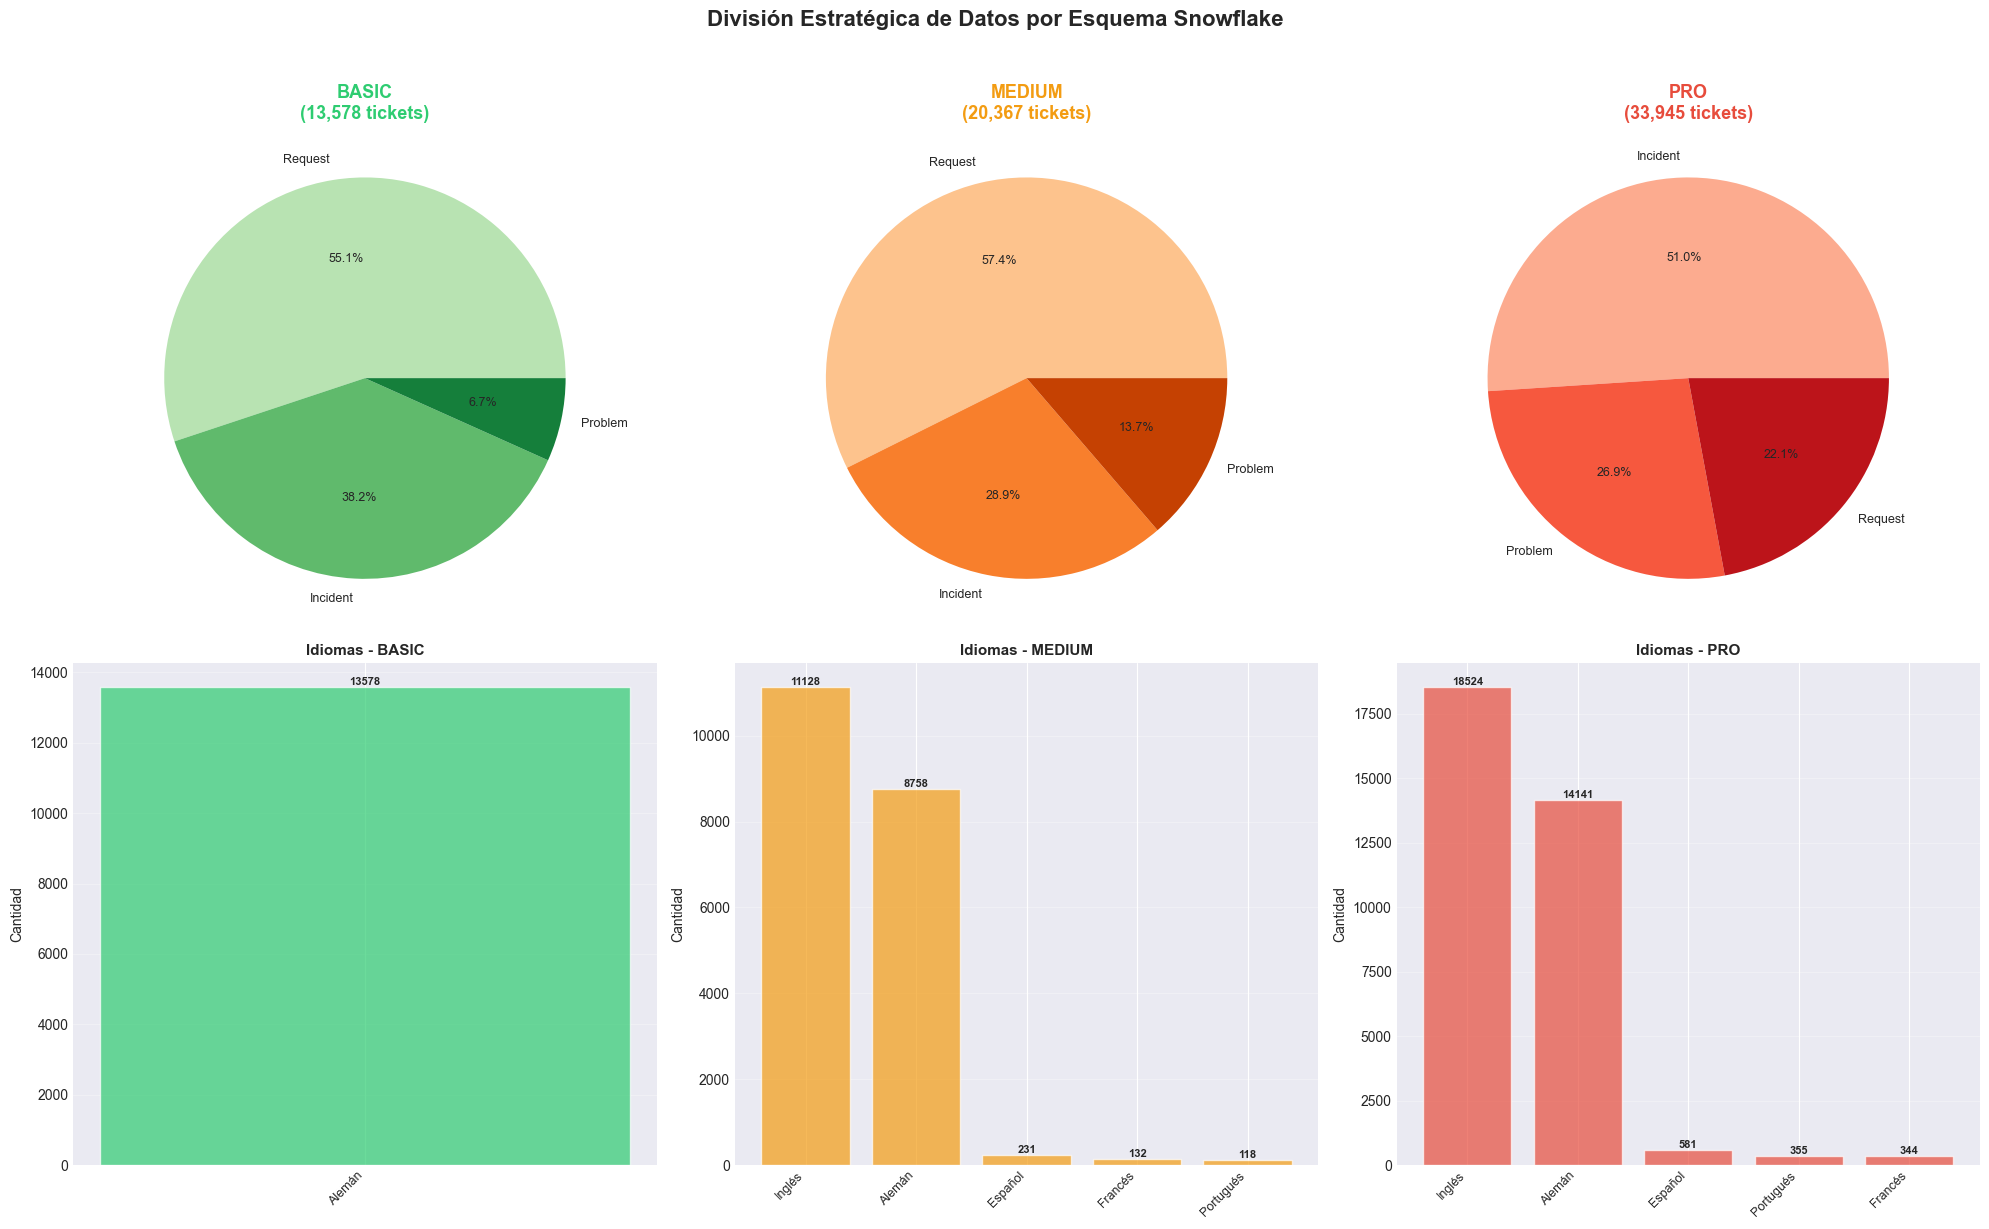

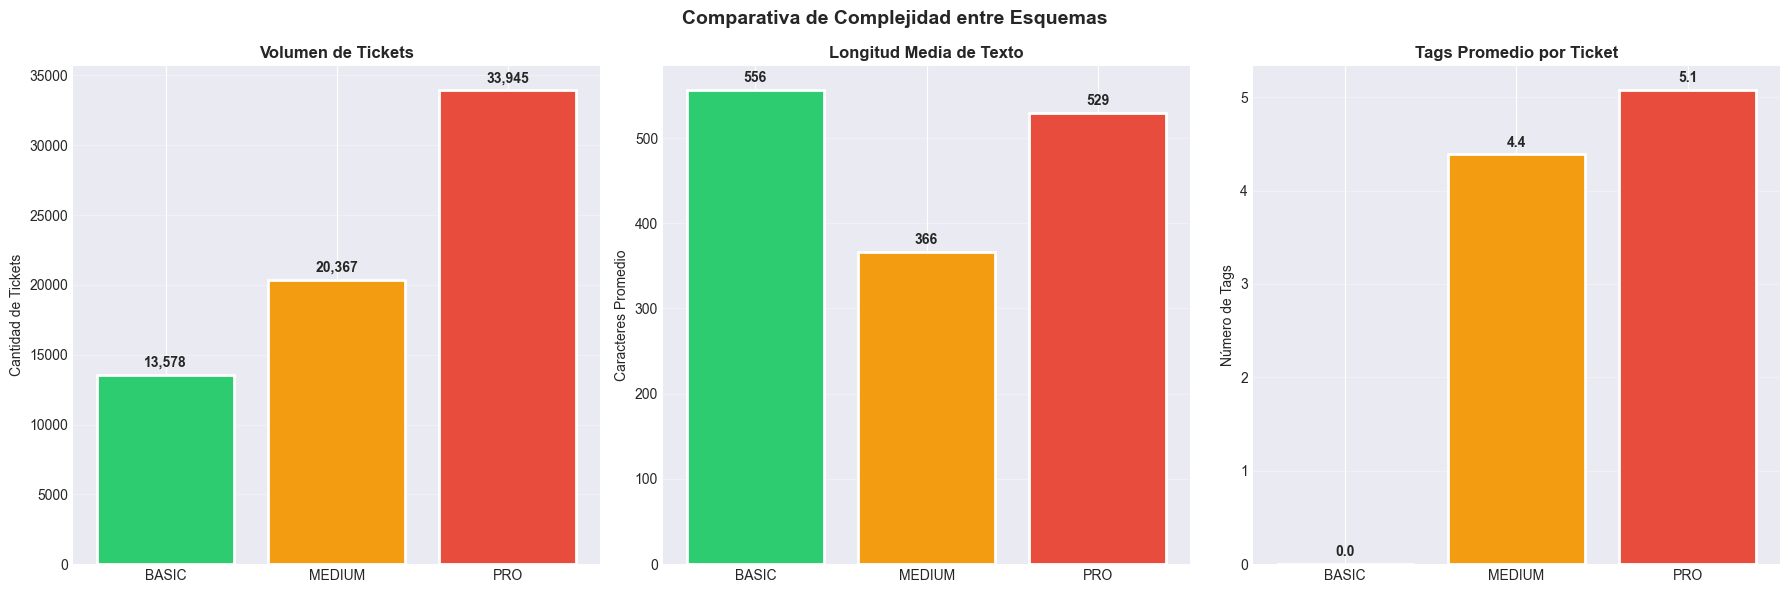

✅ Visualización comparativa completada


In [13]:
# ============================================================================
# VISUALIZACIÓN COMPARATIVA POR ESQUEMA SNOWFLAKE
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('División Estratégica de Datos por Esquema Snowflake', 
             fontsize=16, fontweight='bold', y=1.02)

level_data = {
    'BASIC': {'df': df_basic, 'color': '#2ecc71', 'cmap': 'Greens'},
    'MEDIUM': {'df': df_medium, 'color': '#f39c12', 'cmap': 'Oranges'},
    'PRO': {'df': df_pro, 'color': '#e74c3c', 'cmap': 'Reds'}
}

# Fila 1: Distribución de tipos por esquema
for idx, (level_name, data) in enumerate(level_data.items()):
    subset = data['df']
    ax = axes[0][idx]
    
    if 'type' in subset.columns and len(subset) > 0:
        type_counts = subset['type'].value_counts()
        colors_pie = plt.cm.get_cmap(data['cmap'])(np.linspace(0.3, 0.8, len(type_counts)))
        wedges, texts, autotexts = ax.pie(
            type_counts.values, 
            labels=type_counts.index,
            autopct='%1.1f%%',
            colors=colors_pie,
            textprops={'fontsize': 9}
        )
        ax.set_title(f'{level_name}\n({len(subset):,} tickets)', 
                     fontsize=13, fontweight='bold', color=data['color'])
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=12)
        ax.set_title(f'{level_name}\n(0 tickets)', fontsize=13, fontweight='bold')

# Fila 2: Distribución de idiomas por esquema
lang_col_vis = language_col if language_col in df_ml.columns else 'detected_language'
for idx, (level_name, data) in enumerate(level_data.items()):
    subset = data['df']
    ax = axes[1][idx]
    
    if lang_col_vis in subset.columns and len(subset) > 0:
        lang_counts = subset[lang_col_vis].value_counts()
        lang_labels = [language_names.get(l, l) for l in lang_counts.index]
        bars = ax.bar(range(len(lang_counts)), lang_counts.values, 
                      color=data['color'], alpha=0.7, edgecolor='white')
        ax.set_xticks(range(len(lang_counts)))
        ax.set_xticklabels(lang_labels, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Cantidad', fontsize=10)
        ax.set_title(f'Idiomas - {level_name}', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Añadir valores sobre las barras
        for bar_item, val in zip(bars, lang_counts.values):
            ax.text(bar_item.get_x() + bar_item.get_width()/2, val + 0.5,
                   str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO RESUMEN: Comparativa entre esquemas
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparativa de Complejidad entre Esquemas', fontsize=14, fontweight='bold')

# 1. Volumen por esquema
volumes = [len(df_basic), len(df_medium), len(df_pro)]
colors_bar = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(['BASIC', 'MEDIUM', 'PRO'], volumes, color=colors_bar, edgecolor='white', linewidth=2)
axes[0].set_title('Volumen de Tickets', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Tickets')
axes[0].grid(axis='y', alpha=0.3)
for bar_item, val in zip(bars, volumes):
    axes[0].text(bar_item.get_x() + bar_item.get_width()/2, val + max(volumes)*0.01,
               f'{val:,}', ha='center', va='bottom', fontweight='bold')

# 2. Complejidad textual promedio por esquema
if 'text_length' in df_ml.columns:
    avg_lengths = [
        df_basic['text_length'].mean() if len(df_basic) > 0 else 0,
        df_medium['text_length'].mean() if len(df_medium) > 0 else 0,
        df_pro['text_length'].mean() if len(df_pro) > 0 else 0
    ]
    bars2 = axes[1].bar(['BASIC', 'MEDIUM', 'PRO'], avg_lengths, color=colors_bar, edgecolor='white', linewidth=2)
    axes[1].set_title('Longitud Media de Texto', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Caracteres Promedio')
    axes[1].grid(axis='y', alpha=0.3)
    for bar_item, val in zip(bars2, avg_lengths):
        axes[1].text(bar_item.get_x() + bar_item.get_width()/2, val + max(avg_lengths)*0.01,
                   f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

# 3. Número medio de tags por esquema
tag_columns = [col for col in df_ml.columns if col.startswith('tag_')]
if tag_columns:
    avg_tags = [
        df_basic[tag_columns].notna().sum(axis=1).mean() if len(df_basic) > 0 else 0,
        df_medium[tag_columns].notna().sum(axis=1).mean() if len(df_medium) > 0 else 0,
        df_pro[tag_columns].notna().sum(axis=1).mean() if len(df_pro) > 0 else 0
    ]
    bars3 = axes[2].bar(['BASIC', 'MEDIUM', 'PRO'], avg_tags, color=colors_bar, edgecolor='white', linewidth=2)
    axes[2].set_title('Tags Promedio por Ticket', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Número de Tags')
    axes[2].grid(axis='y', alpha=0.3)
    for bar_item, val in zip(bars3, avg_tags):
        axes[2].text(bar_item.get_x() + bar_item.get_width()/2, val + max(avg_tags)*0.01,
                   f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualización comparativa completada")

### 3.1.2 Mapeo ETL: Columnas del Dataset → Tablas del Esquema

Para cada nivel de esquema, definimos qué columnas del dataset alimentan cada tabla dimensional del Data Warehouse. Este mapeo es la base del pipeline ETL.

In [14]:
# ============================================================================
# MAPEO ETL: COLUMNAS REALES DEL DATASET → TABLAS POR ESQUEMA
# ============================================================================
# Solo mapeamos las columnas que REALMENTE existen en el dataset unificado:
# subject, body, answer, type, queue, priority, language, version, tag_1..tag_8
# + derivadas: text_length, word_count, snowflake_level
# ============================================================================

available_cols = set(df_ml.columns.tolist())
tag_cols_available = [c for c in available_cols if c.startswith('tag_')]

print("=" * 80)
print("MAPEO ETL: COLUMNAS REALES → TABLAS DEL ESQUEMA SNOWFLAKE")
print("=" * 80)
print(f"\n📋 Columnas disponibles en dataset: {sorted([c for c in available_cols if not c.startswith('tag_')])}")
print(f"🏷️  Tags disponibles: {len(tag_cols_available)} ({', '.join(sorted(tag_cols_available))})\n")

# Mapeo REALISTA basado en columnas que existen en nuestro dataset
etl_mapping = {
    'BASIC': {
        'fact_tickets': {
            'direct': ['type', 'priority'],
            'derived': ['ticket_id (generado)', 'created_at (generado)', 'resolution_time_hours (calculado)']
        },
        'dim_date': {'derived_from': 'created_at (se generará en deploy)'},
        'dim_priority': {'direct': ['priority']},
        'dim_type': {'direct': ['type']},
        'ticket_text': {'direct': ['subject', 'body']}
    },
    'MEDIUM': {
        'fact_tickets': {
            'direct': ['type', 'priority', 'queue'],
            'derived': ['ticket_id (generado)', 'created_at (generado)']
        },
        'dim_date': {'derived_from': 'created_at (se generará en deploy)'},
        'dim_priority': {'direct': ['priority']},
        'dim_type': {'direct': ['type']},
        'dim_queue': {'direct': ['queue']},
        'dim_language': {'direct': ['language']},
        'dim_product': {'direct': ['version']},
        'ticket_text': {'direct': ['subject', 'body', 'answer']}
    },
    'PRO': {
        'fact_tickets': {
            'direct': ['type', 'priority', 'queue', 'language'],
            'derived': ['ticket_id (generado)', 'created_at (generado)',
                       'word_count (calculado)', 'text_length (calculado)']
        },
        'dim_date': {'derived_from': 'created_at (se generará en deploy)'},
        'dim_time': {'derived_from': 'created_at (se generará en deploy)'},
        'dim_priority': {'direct': ['priority']},
        'dim_type': {'direct': ['type']},
        'dim_queue': {'direct': ['queue']},
        'dim_language': {'direct': ['language']},
        'dim_product': {'direct': ['version']},
        'dim_tag': {'direct': tag_cols_available},
        'bridge_ticket_tags': {'bridge_from': 'tag_1..tag_8'},
        'ticket_text': {'direct': ['subject', 'body', 'answer']}
    }
}

# Analizar cobertura para cada nivel
for level_name in ['BASIC', 'MEDIUM', 'PRO']:
    icon = {'BASIC': '🟢', 'MEDIUM': '🟡', 'PRO': '🔴'}[level_name]
    mapping = etl_mapping[level_name]
    
    print(f"\n{icon} ESQUEMA {level_name}")
    print(f"{'─' * 60}")
    print(f"  Tablas: {len(mapping)}")
    
    for table_name, config in mapping.items():
        if 'derived_from' in config:
            print(f"  🔧 {table_name} → {config['derived_from']}")
        elif 'bridge_from' in config:
            print(f"  🔗 {table_name} → bridge many-to-many desde {config['bridge_from']}")
        else:
            direct = config.get('direct', [])
            derived = config.get('derived', [])
            direct_found = [c for c in direct if c in available_cols]
            
            if len(direct_found) == len(direct):
                status = "✅"
            elif len(direct_found) > 0:
                status = "⚠️"
            else:
                status = "❌"
            
            cols_str = ', '.join(direct_found)
            if derived:
                cols_str += f" + {len(derived)} derivadas"
            print(f"  {status} {table_name} → [{cols_str}]")

# Dimensionamiento estimado
print("\n\n" + "=" * 80)
print("DIMENSIONAMIENTO ESTIMADO POR ESQUEMA")
print("=" * 80 + "\n")

schema_stats = {}
for level_name, subset in [('BASIC', df_basic), ('MEDIUM', df_medium), ('PRO', df_pro)]:
    n_rows = len(subset)
    n_tables = len(etl_mapping[level_name])
    estimated_dim_rows = {'BASIC': n_rows * 1.3, 'MEDIUM': n_rows * 2.5, 'PRO': n_rows * 4.0}
    estimated_size_mb = (estimated_dim_rows[level_name] * 200) / (1024 * 1024)
    
    schema_stats[level_name] = {
        'tickets': n_rows, 'tables': n_tables,
        'estimated_total_rows': int(estimated_dim_rows[level_name]),
        'estimated_size_mb': estimated_size_mb
    }
    
    icon = {'BASIC': '🟢', 'MEDIUM': '🟡', 'PRO': '🔴'}[level_name]
    print(f"{icon} {level_name}: {n_rows:,} tickets → {n_tables} tablas → ~{estimated_size_mb:.1f} MB")

strategic_splits = {
    'BASIC': df_basic, 'MEDIUM': df_medium, 'PRO': df_pro,
    'stats': schema_stats, 'etl_mapping': etl_mapping
}

print("\n✅ Mapeo ETL completado (solo columnas reales del dataset)")

MAPEO ETL: COLUMNAS REALES → TABLAS DEL ESQUEMA SNOWFLAKE

📋 Columnas disponibles en dataset: ['answer', 'body', 'body_length', 'complexity_score', 'language', 'priority', 'queue', 'snowflake_level', 'subject', 'subject_length', 'text_combined', 'text_length', 'type', 'version', 'word_count']
🏷️  Tags disponibles: 8 (tag_1, tag_2, tag_3, tag_4, tag_5, tag_6, tag_7, tag_8)


🟢 ESQUEMA BASIC
────────────────────────────────────────────────────────────
  Tablas: 5
  ✅ fact_tickets → [type, priority + 3 derivadas]
  🔧 dim_date → created_at (se generará en deploy)
  ✅ dim_priority → [priority]
  ✅ dim_type → [type]
  ✅ ticket_text → [subject, body]

🟡 ESQUEMA MEDIUM
────────────────────────────────────────────────────────────
  Tablas: 8
  ✅ fact_tickets → [type, priority, queue + 2 derivadas]
  🔧 dim_date → created_at (se generará en deploy)
  ✅ dim_priority → [priority]
  ✅ dim_type → [type]
  ✅ dim_queue → [queue]
  ✅ dim_language → [language]
  ✅ dim_product → [version]
  ✅ ticket_text 

In [15]:
# ============================================================================
# EXPORTACIÓN ESTRATÉGICA: DATOS SEPARADOS POR ESQUEMA
# ============================================================================
# Se exportan a data/processed/ (NO a model_artifacts/ — eso es solo para .pkl)
# ============================================================================

import os

output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

print("=" * 80)
print("EXPORTACIÓN DE DATOS POR ESQUEMA SNOWFLAKE")
print("=" * 80 + "\n")

# Columnas reales disponibles por nivel (solo las que existen)
def get_real_columns(level, df_subset):
    """Devuelve columnas REALES que existen en el subset."""
    base_cols = ['subject', 'body', 'type', 'priority', 'snowflake_level']
    
    lang_c = language_col if language_col in df_subset.columns else 'language'
    if lang_c in df_subset.columns:
        base_cols.append(lang_c)
    
    if level == 'MEDIUM':
        base_cols += ['queue', 'version', 'answer']
    elif level == 'PRO':
        base_cols += ['queue', 'version', 'answer', 'text_length', 'word_count']
        base_cols += [c for c in df_subset.columns if c.startswith('tag_')]
    
    return [c for c in base_cols if c in df_subset.columns]

for level_name, subset in [('BASIC', df_basic), ('MEDIUM', df_medium), ('PRO', df_pro)]:
    if len(subset) == 0:
        print(f"⚠️  {level_name}: Sin tickets, saltando exportación")
        continue
    
    relevant_cols = get_real_columns(level_name, subset)
    export_df = subset[relevant_cols].copy()
    
    filename = f'data_split_{level_name.lower()}.csv'
    filepath = os.path.join(output_dir, filename)
    export_df.to_csv(filepath, index=False, encoding='utf-8')
    
    icon = {'BASIC': '🟢', 'MEDIUM': '🟡', 'PRO': '🔴'}[level_name]
    print(f"{icon} {level_name}:")
    print(f"   Archivo: {filepath}")
    print(f"   Tickets: {len(export_df):,}")
    print(f"   Columnas ({len(relevant_cols)}): {', '.join(relevant_cols)}")
    print(f"   Tamaño: {os.path.getsize(filepath) / 1024:.1f} KB\n")

# Resumen
print("=" * 80)
print("RESUMEN FINAL: DIVISIÓN ESTRATÉGICA")
print("=" * 80 + "\n")

summary_data = []
for level_name, subset in [('BASIC', df_basic), ('MEDIUM', df_medium), ('PRO', df_pro)]:
    lang_c = language_col if language_col in subset.columns else 'language'
    summary_data.append({
        'Esquema': level_name,
        'Tickets': len(subset),
        '% Total': f"{len(subset)/total*100:.1f}%",
        'Idiomas': subset[lang_c].nunique() if lang_c in subset.columns and len(subset) > 0 else 0,
        'Tipos': subset['type'].nunique() if 'type' in subset.columns and len(subset) > 0 else 0,
        'Tablas DW': len(etl_mapping[level_name]),
        'Cols Export': len(get_real_columns(level_name, subset))
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n✅ Datos exportados a {output_dir}/")
print(f"📦 model_artifacts/ queda reservado SOLO para modelos entrenados (.pkl)")

EXPORTACIÓN DE DATOS POR ESQUEMA SNOWFLAKE

🟢 BASIC:
   Archivo: ../data/processed\data_split_basic.csv
   Tickets: 13,578
   Columnas (6): subject, body, type, priority, snowflake_level, language
   Tamaño: 7861.2 KB

🟡 MEDIUM:
   Archivo: ../data/processed\data_split_medium.csv
   Tickets: 20,367
   Columnas (9): subject, body, type, priority, snowflake_level, language, queue, version, answer
   Tamaño: 15390.7 KB

🔴 PRO:
   Archivo: ../data/processed\data_split_pro.csv
   Tickets: 33,945
   Columnas (19): subject, body, type, priority, snowflake_level, language, queue, version, answer, text_length, word_count, tag_1, tag_2, tag_3, tag_4, tag_5, tag_6, tag_7, tag_8
   Tamaño: 36053.5 KB

RESUMEN FINAL: DIVISIÓN ESTRATÉGICA

Esquema  Tickets % Total  Idiomas  Tipos  Tablas DW  Cols Export
  BASIC    13578   20.0%        1      3          5            6
 MEDIUM    20367   30.0%        5      3          8            9
    PRO    33945   50.0%        5      3         11           19

✅ D

### 3.2 Codificación de Variables Categóricas

In [16]:
# Codificar variables categóricas
label_encoders = {}

for col in categorical_features:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col])
        label_encoders[col] = le
        print(f"✓ Variable '{col}' codificada: {len(le.classes_)} categorías únicas")

✓ Variable 'queue' codificada: 62 categorías únicas
✓ Variable 'priority' codificada: 5 categorías únicas
✓ Variable 'language' codificada: 5 categorías únicas


### 3.3 Vectorización de Texto con TF-IDF

In [17]:
# Vectorización de texto usando TF-IDF
print("\n📝 Aplicando TF-IDF Vectorization...\n")

tfidf = TfidfVectorizer(
    max_features=100,  # Limitar a las 100 características más importantes
    min_df=2,           # Ignorar términos que aparecen en menos de 2 documentos
    max_df=0.8,         # Ignorar términos que aparecen en más del 80% de los documentos
    ngram_range=(1, 2), # Usar unigramas y bigramas
    stop_words='english'
)

text_features = tfidf.fit_transform(df_ml['text_combined'])
text_features_df = pd.DataFrame(
    text_features.toarray(), 
    columns=[f'tfidf_{i}' for i in range(text_features.shape[1])]
)

print(f"✓ Vectorización completada: {text_features.shape[1]} características de texto generadas")


📝 Aplicando TF-IDF Vectorization...

✓ Vectorización completada: 100 características de texto generadas


### 3.4 Creación de Dataset Final Multi-Objetivo

Crearemos un dataset que permita entrenar modelos para predecir simultáneamente:
- Tipo de ticket
- Idioma  
- Nivel de Snowflake DW necesario

In [18]:
# Combinar todas las features
feature_cols = [f'{col}_encoded' for col in categorical_features if col in df_ml.columns]
feature_cols += ['subject_length', 'body_length', 'text_length', 'word_count']

# Crear matriz de features X
X_categorical = df_ml[feature_cols].values
X_combined = np.hstack([X_categorical, text_features.toarray()])

# Variables objetivo múltiples
y_type = np.array(df_ml['type'].astype(str))
y_language = np.array(df_ml[language_col].astype(str))
y_snowflake = np.array(df_ml['snowflake_level'].astype(str))

print("\n" + "="*80)
print("DATASET FINAL PARA MACHINE LEARNING MULTI-OBJETIVO")
print("="*80 + "\n")
print(f"📊 Dimensiones de X (features): {X_combined.shape}")
print(f"📊 Dimensiones de y_type (tipo): {y_type.shape}")
print(f"📊 Dimensiones de y_language (idioma): {y_language.shape}")
print(f"📊 Dimensiones de y_snowflake (nivel DW): {y_snowflake.shape}")
print(f"\n✓ Total de features utilizadas: {X_combined.shape[1]}")
print(f"  - Features categóricas: {len(feature_cols) - 4}")
print(f"  - Features de longitud de texto: 4")
print(f"  - Features TF-IDF: {text_features.shape[1]}")

# Distribución de las variables objetivo
print("\n" + "="*80)
print("DISTRIBUCIÓN DE VARIABLES OBJETIVO")
print("="*80 + "\n")

print("Tipo de Ticket:")
for tipo, count in pd.Series(y_type).value_counts().items():
    print(f"  {tipo}: {count} ({count/len(y_type)*100:.1f}%)")

print("\nIdioma:")
for lang, count in pd.Series(y_language).value_counts().items():
    lang_name = language_names.get(lang, lang)
    print(f"  {lang_name} ({lang}): {count} ({count/len(y_language)*100:.1f}%)")

print("\nNivel Snowflake DW:")
for level, count in pd.Series(y_snowflake).value_counts().items():
    print(f"  {level}: {count} ({count/len(y_snowflake)*100:.1f}%)")


DATASET FINAL PARA MACHINE LEARNING MULTI-OBJETIVO

📊 Dimensiones de X (features): (67890, 107)
📊 Dimensiones de y_type (tipo): (67890,)
📊 Dimensiones de y_language (idioma): (67890,)
📊 Dimensiones de y_snowflake (nivel DW): (67890,)

✓ Total de features utilizadas: 107
  - Features categóricas: 3
  - Features de longitud de texto: 4
  - Features TF-IDF: 100

DISTRIBUCIÓN DE VARIABLES OBJETIVO

Tipo de Ticket:
  Incident: 28404 (41.8%)
  Request: 26665 (39.3%)
  Problem: 12821 (18.9%)

Idioma:
  Alemán (de): 36477 (53.7%)
  Inglés (en): 29652 (43.7%)
  Español (es): 812 (1.2%)
  Francés (fr): 476 (0.7%)
  Portugués (pt): 473 (0.7%)

Nivel Snowflake DW:
  PRO: 33945 (50.0%)
  MEDIUM: 20367 (30.0%)
  BASIC: 13578 (20.0%)


### 3.5 División en Conjuntos de Entrenamiento y Test

In [19]:
# Dividir datos en train y test con estratificación
# Usaremos el tipo de ticket para estratificar ya que es la variable más importante
X_train, X_test, y_type_train, y_type_test, y_lang_train, y_lang_test, y_snow_train, y_snow_test = train_test_split(
    X_combined, y_type, y_language, y_snowflake,
    test_size=0.2, 
    random_state=42, 
    stratify=y_type
)

print("\n" + "="*80)
print("DIVISIÓN DE DATOS")
print("="*80 + "\n")
print(f"📈 Conjunto de entrenamiento: {X_train.shape[0]:,} instancias ({X_train.shape[0]/len(X_combined)*100:.1f}%)")
print(f"📉 Conjunto de test: {X_test.shape[0]:,} instancias ({X_test.shape[0]/len(X_combined)*100:.1f}%)")

# Verificar distribución de clases en train y test para cada objetivo
print("\n" + "="*80)
print("📊 DISTRIBUCIÓN DE TIPO DE TICKET")
print("="*80)
print("\nTRAIN:")
for cls, count in pd.Series(y_type_train).value_counts().items():
    print(f"   {cls}: {count} ({count/len(y_type_train)*100:.1f}%)")
print("\nTEST:")
for cls, count in pd.Series(y_type_test).value_counts().items():
    print(f"   {cls}: {count} ({count/len(y_type_test)*100:.1f}%)")

print("\n" + "="*80)
print("🌍 DISTRIBUCIÓN DE IDIOMAS")
print("="*80)
print("\nTRAIN:")
for cls, count in pd.Series(y_lang_train).value_counts().items():
    print(f"   {language_names.get(cls, cls)}: {count} ({count/len(y_lang_train)*100:.1f}%)")
print("\nTEST:")
for cls, count in pd.Series(y_lang_test).value_counts().items():
    print(f"   {language_names.get(cls, cls)}: {count} ({count/len(y_lang_test)*100:.1f}%)")

print("\n" + "="*80)
print("🏢 DISTRIBUCIÓN DE NIVEL SNOWFLAKE")
print("="*80)
print("\nTRAIN:")
for cls, count in pd.Series(y_snow_train).value_counts().items():
    print(f"   {cls}: {count} ({count/len(y_snow_train)*100:.1f}%)")
print("\nTEST:")
for cls, count in pd.Series(y_snow_test).value_counts().items():
    print(f"   {cls}: {count} ({count/len(y_snow_test)*100:.1f}%)")


DIVISIÓN DE DATOS

📈 Conjunto de entrenamiento: 54,312 instancias (80.0%)
📉 Conjunto de test: 13,578 instancias (20.0%)

📊 DISTRIBUCIÓN DE TIPO DE TICKET

TRAIN:
   Incident: 22723 (41.8%)
   Request: 21332 (39.3%)
   Problem: 10257 (18.9%)

TEST:
   Incident: 5681 (41.8%)
   Request: 5333 (39.3%)
   Problem: 2564 (18.9%)

🌍 DISTRIBUCIÓN DE IDIOMAS

TRAIN:
   Alemán: 29247 (53.8%)
   Inglés: 23693 (43.6%)
   Español: 633 (1.2%)
   Portugués: 379 (0.7%)
   Francés: 360 (0.7%)

TEST:
   Alemán: 7230 (53.2%)
   Inglés: 5959 (43.9%)
   Español: 179 (1.3%)
   Francés: 116 (0.9%)
   Portugués: 94 (0.7%)

🏢 DISTRIBUCIÓN DE NIVEL SNOWFLAKE

TRAIN:
   PRO: 27064 (49.8%)
   MEDIUM: 16325 (30.1%)
   BASIC: 10923 (20.1%)

TEST:
   PRO: 6881 (50.7%)
   MEDIUM: 4042 (29.8%)
   BASIC: 2655 (19.6%)


**¿Por qué es necesaria esta separación?**

1. **Evitar sobreajuste (overfitting):** El conjunto de test actúa como datos "no vistos" para evaluar la capacidad de generalización del modelo
2. **Evaluación realista:** Simula cómo funcionará el modelo con datos nuevos en producción
3. **Validación independiente:** Permite medir el rendimiento real del modelo sin sesgo de entrenamiento
4. **Estratificación:** Mantiene la proporción de clases en ambos conjuntos, crucial para datos desbalanceados

### 3.6 Escalado de Features (Opcional)

In [20]:
# Escalar features (importante para algunos modelos como SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features escaladas con StandardScaler")
print("  (Requerido para modelos sensibles a escala: SVM, KNN, Logistic Regression)")

✓ Features escaladas con StandardScaler
  (Requerido para modelos sensibles a escala: SVM, KNN, Logistic Regression)


## 4. Entrenamiento de Modelos Multi-Objetivo

Entrenaremos modelos de clasificación para cada una de las tres tareas:
1. **Clasificación de Tipo de Ticket** (Incident, Request, Problem)
2. **Detección de Idioma** (en, es, de, fr, pt)
3. **Determinación de Nivel Snowflake** (BasicMEDIUM, PRO)

### 4.1 Definición de Modelos

In [21]:
# Diccionario de modelos a evaluar (con n_jobs=-1 para máximo paralelismo)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'SVM (Linear)': LinearSVC(random_state=42, class_weight='balanced', max_iter=2000, dual='auto'),
    'Naive Bayes': GaussianNB(),
}

print("\n" + "="*80)
print("MODELOS A EVALUAR")
print("="*80 + "\n")
for i, (name, model) in enumerate(models.items(), 1):
    print(f"{i}. {name}")
print(f"\n✓ Total de modelos: {len(models)}")
print("\n📋 Cada modelo será entrenado para 3 tareas:")
print("   1. Clasificación de Tipo de Ticket")
print("   2. Detección de Idioma")
print("   3. Determinación de Nivel Snowflake DW")


MODELOS A EVALUAR

1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. SVM (Linear)
5. Naive Bayes

✓ Total de modelos: 5

📋 Cada modelo será entrenado para 3 tareas:
   1. Clasificación de Tipo de Ticket
   2. Detección de Idioma
   3. Determinación de Nivel Snowflake DW


### 4.2 Entrenamiento Multiobjetivo

In [22]:
import time
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

# Escalar features (necesario para LR y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SCALED_MODELS = {'Logistic Regression', 'SVM (Linear)'}

# Diccionarios para almacenar resultados
results_type = {}
results_language = {}
results_snowflake = {}

# Lock para prints seguros desde múltiples threads
print_lock = threading.Lock()
# Timestamps de inicio por modelo (para calcular tiempo individual)
model_start_times = {}


def train_single(model_name, model_template, task_name, X_tr, X_te, y_tr):
    """Entrena un modelo clonado y devuelve predicciones train/test."""
    m = clone(model_template)
    m.fit(X_tr, y_tr)
    return model_name, task_name, m, m.predict(X_tr), m.predict(X_te)


print("\n" + "="*80)
print("ENTRENAMIENTO DE MODELOS MULTI-OBJETIVO — MÁXIMO PARALELISMO")
print(f"🚀 Lanzando {len(models)} modelos × 3 tareas = {len(models)*3} threads simultáneos")
print("="*80)

t_total_start = time.time()

# Preparar las 15 combinaciones (5 modelos × 3 tareas)
jobs = []
for model_name, model_template in models.items():
    X_tr = X_train_scaled if model_name in SCALED_MODELS else X_train
    X_te = X_test_scaled  if model_name in SCALED_MODELS else X_test
    model_start_times[model_name] = time.time()

    jobs.append((model_name, model_template, 'type',      X_tr, X_te, y_type_train))
    jobs.append((model_name, model_template, 'language',   X_tr, X_te, y_lang_train))
    jobs.append((model_name, model_template, 'snowflake',  X_tr, X_te, y_snow_train))

# Lanzar TODOS los 15 threads a la vez
# Tracker para saber cuándo un modelo tiene sus 3 tareas completas
model_results = {name: {} for name in models}
models_printed = set()

with ThreadPoolExecutor(max_workers=len(jobs)) as executor:
    futures = {executor.submit(train_single, *job): job for job in jobs}

    for future in as_completed(futures):
        model_name, task_name, model_obj, y_tr_pred, y_te_pred = future.result()

        result = {
            'model': model_obj,
            'y_train_pred': y_tr_pred,
            'y_test_pred': y_te_pred
        }

        # Guardar en dicts globales
        if task_name == 'type':
            results_type[model_name] = result
        elif task_name == 'language':
            results_language[model_name] = result
        elif task_name == 'snowflake':
            results_snowflake[model_name] = result

        model_results[model_name][task_name] = result

        # Cuando un modelo tiene las 3 tareas listas → imprimir resumen
        with print_lock:
            if len(model_results[model_name]) == 3 and model_name not in models_printed:
                models_printed.add(model_name)
                t_model = time.time() - model_start_times[model_name]

                acc_type = accuracy_score(y_type_test, results_type[model_name]['y_test_pred'])
                acc_lang = accuracy_score(y_lang_test, results_language[model_name]['y_test_pred'])
                acc_snow = accuracy_score(y_snow_test, results_snowflake[model_name]['y_test_pred'])

                print(f"\n{'─'*80}")
                print(f"✅ {model_name}  ({t_model:.1f}s)")
                print(f"{'─'*80}")
                print(f"   📋 Type accuracy:      {acc_type:.4f}")
                print(f"   🌍 Language accuracy:   {acc_lang:.4f}")
                print(f"   🏢 Snowflake accuracy:  {acc_snow:.4f}")

t_total = time.time() - t_total_start

print(f"\n{'='*80}")
print(f"✅ {len(models)} modelos × 3 tareas = {len(models)*3} clasificadores entrenados")
print(f"⏱️  Tiempo total: {t_total:.1f}s  ({len(jobs)} threads simultáneos)")
print(f"{'='*80}")


ENTRENAMIENTO DE MODELOS MULTI-OBJETIVO — MÁXIMO PARALELISMO
🚀 Lanzando 5 modelos × 3 tareas = 15 threads simultáneos

────────────────────────────────────────────────────────────────────────────────
✅ SVM (Linear)  (56.6s)
────────────────────────────────────────────────────────────────────────────────
   📋 Type accuracy:      0.6834
   🌍 Language accuracy:   0.9909
   🏢 Snowflake accuracy:  0.8010

────────────────────────────────────────────────────────────────────────────────
✅ Naive Bayes  (119.3s)
────────────────────────────────────────────────────────────────────────────────
   📋 Type accuracy:      0.5565
   🌍 Language accuracy:   1.0000
   🏢 Snowflake accuracy:  0.6300

────────────────────────────────────────────────────────────────────────────────
✅ Random Forest  (137.5s)
────────────────────────────────────────────────────────────────────────────────
   📋 Type accuracy:      0.7210
   🌍 Language accuracy:   0.9883
   🏢 Snowflake accuracy:  0.8369

───────────────────────

## 5. Evaluación de Modelos Multi-Objetivo

Evaluaremos el rendimiento de cada modelo en las tres tareas de clasificación.

### 5.1 Métricas de Rendimiento


MÉTRICAS DE RENDIMIENTO - RESUMEN POR TAREA

📋 TAREA 1: CLASIFICACIÓN DE TIPO DE TICKET
--------------------------------------------------------------------------------
             Modelo  Accuracy  Precision  Recall  F1-Score
       SVM (Linear)    0.6834     0.6602  0.6834    0.6677
        Naive Bayes    0.5565     0.6248  0.5565    0.5612
      Random Forest    0.7210     0.7417  0.7210    0.7267
Logistic Regression    0.6447     0.6839  0.6447    0.6525
  Gradient Boosting    0.7301     0.7140  0.7301    0.6921


🌍 TAREA 2: DETECCIÓN DE IDIOMA
--------------------------------------------------------------------------------
             Modelo  Accuracy  Precision  Recall  F1-Score
       SVM (Linear)    0.9909     0.9916  0.9909    0.9908
        Naive Bayes    1.0000     1.0000  1.0000    1.0000
      Random Forest    0.9883     0.9886  0.9883    0.9883
Logistic Regression    0.9999     0.9999  0.9999    0.9999
  Gradient Boosting    1.0000     1.0000  1.0000    1.0000


🏢 TARE

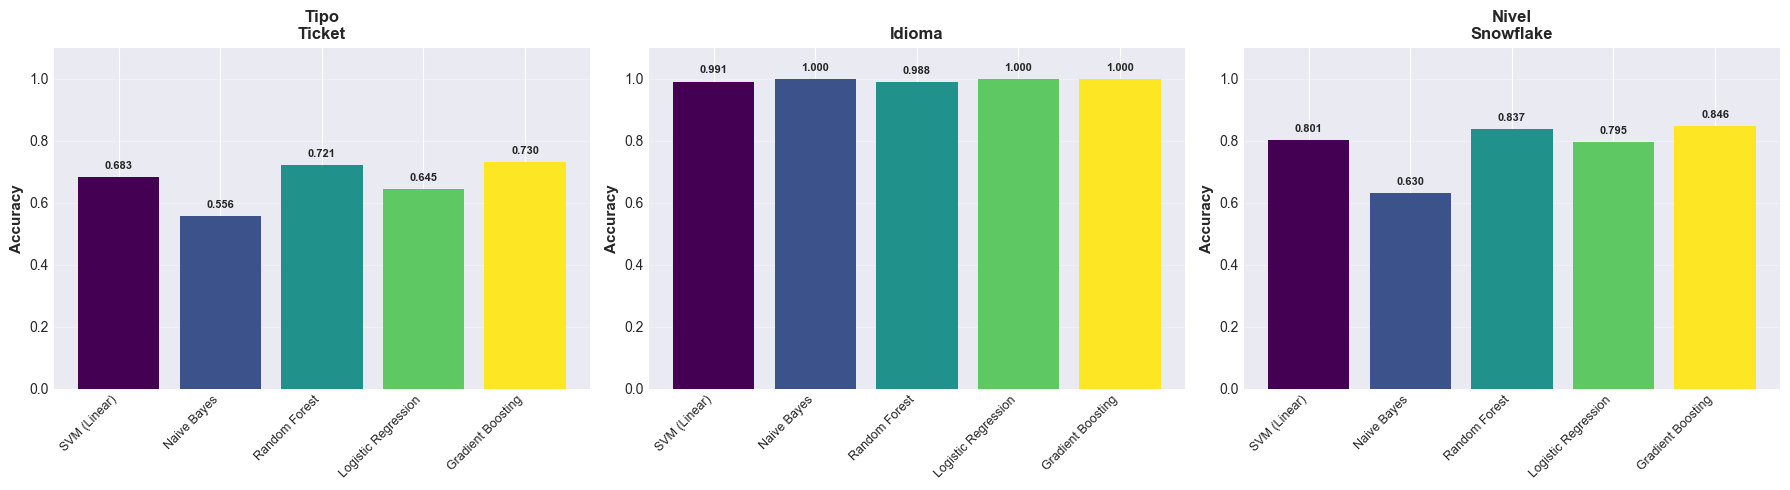


🏆 MEJORES MODELOS POR TAREA

📋 Clasificación de Tipo: Random Forest (F1-Score: 0.7267)
🌍 Detección de Idioma: Naive Bayes (F1-Score: 1.0000)
🏢 Nivel Snowflake: Gradient Boosting (F1-Score: 0.8458)


In [23]:
# Función para calcular métricas
def calculate_metrics(y_true, y_pred, task_name):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# Calcular métricas para cada tarea
print("\n" + "="*80)
print("MÉTRICAS DE RENDIMIENTO - RESUMEN POR TAREA")
print("="*80 + "\n")

# Tarea 1: Tipo de Ticket
print("📋 TAREA 1: CLASIFICACIÓN DE TIPO DE TICKET")
print("-" * 80)
metrics_type = []
for name, result in results_type.items():
    metrics = calculate_metrics(y_type_test, result['y_test_pred'], 'Type')
    metrics['Modelo'] = name
    metrics_type.append(metrics)

df_metrics_type = pd.DataFrame(metrics_type).round(4)
df_metrics_type = df_metrics_type[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print(df_metrics_type.to_string(index=False))

# Tarea 2: Detección de Idioma
print("\n\n🌍 TAREA 2: DETECCIÓN DE IDIOMA")
print("-" * 80)
metrics_lang = []
for name, result in results_language.items():
    metrics = calculate_metrics(y_lang_test, result['y_test_pred'], 'Language')
    metrics['Modelo'] = name
    metrics_lang.append(metrics)

df_metrics_lang = pd.DataFrame(metrics_lang).round(4)
df_metrics_lang = df_metrics_lang[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print(df_metrics_lang.to_string(index=False))

# Tarea 3: Nivel Snowflake
print("\n\n🏢 TAREA 3: DETERMINACIÓN DE NIVEL SNOWFLAKE DW")
print("-" * 80)
metrics_snow = []
for name, result in results_snowflake.items():
    metrics = calculate_metrics(y_snow_test, result['y_test_pred'], 'Snowflake')
    metrics['Modelo'] = name
    metrics_snow.append(metrics)

df_metrics_snow = pd.DataFrame(metrics_snow).round(4)
df_metrics_snow = df_metrics_snow[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print(df_metrics_snow.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Accuracypor tarea
tasks = ['Tipo\nTicket', 'Idioma', 'Nivel\nSnowflake']
for idx, df_metrics in enumerate([df_metrics_type, df_metrics_lang, df_metrics_snow]):
    x = np.arange(len(df_metrics))
    axes[idx].bar(x, df_metrics['Accuracy'], color=plt.cm.viridis(np.linspace(0, 1, len(df_metrics))))
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(df_metrics['Modelo'], rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{tasks[idx]}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0, 1.1])
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Añadir valores
    for i, v in enumerate(df_metrics['Accuracy']):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Identificar mejores modelos por tarea
best_type = df_metrics_type.loc[df_metrics_type['F1-Score'].idxmax(), 'Modelo']
best_lang = df_metrics_lang.loc[df_metrics_lang['F1-Score'].idxmax(), 'Modelo']
best_snow = df_metrics_snow.loc[df_metrics_snow['F1-Score'].idxmax(), 'Modelo']

print("\n" + "="*80)
print("🏆 MEJORES MODELOS POR TAREA")
print("="*80)
print(f"\n📋 Clasificación de Tipo: {best_type} (F1-Score: {df_metrics_type.loc[df_metrics_type['Modelo'] == best_type, 'F1-Score'].values[0]:.4f})")
print(f"🌍 Detección de Idioma: {best_lang} (F1-Score: {df_metrics_lang.loc[df_metrics_lang['Modelo'] == best_lang, 'F1-Score'].values[0]:.4f})")
print(f"🏢 Nivel Snowflake: {best_snow} (F1-Score: {df_metrics_snow.loc[df_metrics_snow['Modelo'] == best_snow, 'F1-Score'].values[0]:.4f})")

## 6. Matrices de Confusión Multi-Objetivo

Visualizaremos las matrices de confusión para cada una de las tres tareas de clasificación:
- **Tarea 1:** Clasificación de Tipo de Ticket
- **Tarea 2:** Detección de Idioma  
- **Tarea 3:** Nivel Snowflake Data Warehouse

### 5.2 Visualización de Comparación de Métricas

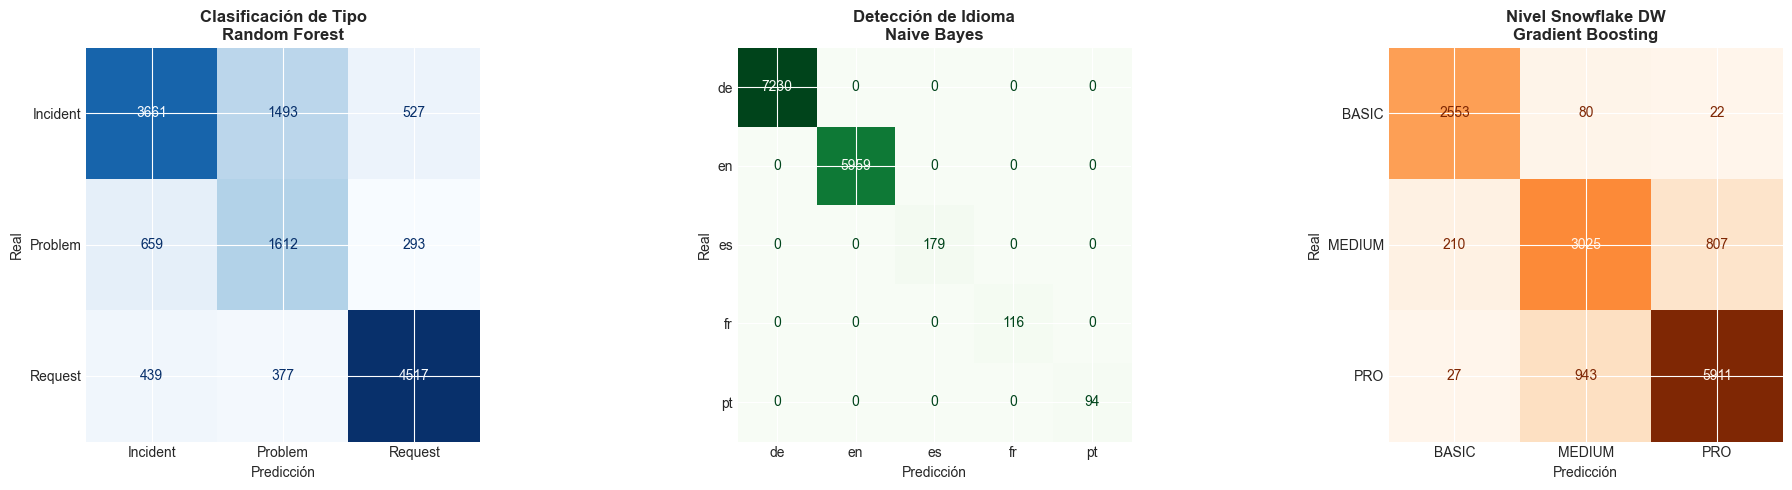

ANÁLISIS DE MATRICES DE CONFUSIÓN

📋 TIPO: Random Forest
   Accuracy: 0.7210

🌍 IDIOMA: Naive Bayes
   Accuracy: 1.0000

🏢 SNOWFLAKE: Gradient Boosting
   Accuracy: 0.8461


In [24]:
# Crear 3 paneles para las matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Tarea 1: Tipo de Ticket
y_pred_type = results_type[best_type]['y_test_pred']
cm_type = confusion_matrix(y_type_test, y_pred_type)
disp_type = ConfusionMatrixDisplay(confusion_matrix=cm_type, display_labels=np.unique(y_type_test))
disp_type.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Clasificación de Tipo\n{best_type}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=10)
axes[0].set_ylabel('Real', fontsize=10)

# Tarea 2: Idioma
y_pred_lang = results_language[best_lang]['y_test_pred']
cm_lang = confusion_matrix(y_lang_test, y_pred_lang)
disp_lang = ConfusionMatrixDisplay(confusion_matrix=cm_lang, display_labels=np.unique(y_lang_test))
disp_lang.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Detección de Idioma\n{best_lang}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=10)
axes[1].set_ylabel('Real', fontsize=10)

# Tarea 3: Nivel Snowflake
y_pred_snow = results_snowflake[best_snow]['y_test_pred']
cm_snow = confusion_matrix(y_snow_test, y_pred_snow)
disp_snow = ConfusionMatrixDisplay(confusion_matrix=cm_snow, display_labels=np.unique(y_snow_test))
disp_snow.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title(f'Nivel Snowflake DW\n{best_snow}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicción', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)

plt.tight_layout()
plt.show()

print("=" * 80)
print("ANÁLISIS DE MATRICES DE CONFUSIÓN")
print("=" * 80)
print(f"\n📋 TIPO: {best_type}")
print(f"   Accuracy: {accuracy_score(y_type_test, y_pred_type):.4f}")
print(f"\n🌍 IDIOMA: {best_lang}")
print(f"   Accuracy: {accuracy_score(y_lang_test, y_pred_lang):.4f}")
print(f"\n🏢 SNOWFLAKE: {best_snow}")
print(f"   Accuracy: {accuracy_score(y_snow_test, y_pred_snow):.4f}")

### Reportes de Clasificación Detallados

In [25]:
# Reportes de clasificación para cada tarea
print("=" * 80)
print("REPORTES DE CLASIFICACIÓN DETALLADOS")
print("=" * 80)

print("\n" + "=" * 80)
print("📋 TAREA 1: CLASIFICACIÓN DE TIPO DE TICKET")
print("=" * 80)
print(f"\nModelo: {best_type}\n")
print(classification_report(y_type_test, y_pred_type))

print("\n" + "=" * 80)
print("🌍 TAREA 2: DETECCIÓN DE IDIOMA")
print("=" * 80)
print(f"\nModelo: {best_lang}\n")
print(classification_report(y_lang_test, y_pred_lang))

print("\n" + "=" * 80)
print("🏢 TAREA 3: NIVEL SNOWFLAKE DATA WAREHOUSE")
print("=" * 80)
print(f"\nModelo: {best_snow}\n")
print(classification_report(y_snow_test, y_pred_snow))

REPORTES DE CLASIFICACIÓN DETALLADOS

📋 TAREA 1: CLASIFICACIÓN DE TIPO DE TICKET

Modelo: Random Forest

              precision    recall  f1-score   support

    Incident       0.77      0.64      0.70      5681
     Problem       0.46      0.63      0.53      2564
     Request       0.85      0.85      0.85      5333

    accuracy                           0.72     13578
   macro avg       0.69      0.71      0.69     13578
weighted avg       0.74      0.72      0.73     13578


🌍 TAREA 2: DETECCIÓN DE IDIOMA

Modelo: Naive Bayes

              precision    recall  f1-score   support

          de       1.00      1.00      1.00      7230
          en       1.00      1.00      1.00      5959
          es       1.00      1.00      1.00       179
          fr       1.00      1.00      1.00       116
          pt       1.00      1.00      1.00        94

    accuracy                           1.00     13578
   macro avg       1.00      1.00      1.00     13578
weighted avg       1.00   

## 7. Validación Cruzada Multi-Objetivo

Evaluaremos la robustez de los modelos usando validación cruzada estratificada para cada tarea.

### 5.4 Reportes de Clasificación Detallados

VALIDACIÓN CRUZADA - EVALUACIÓN DE ROBUSTEZ

📋 TAREA 1: CLASIFICACIÓN DE TIPO
--------------------------------------------------------------------------------
Modelo: Random Forest
F1-Score CV promedio: 0.7255 (+/- 0.0047)
Scores por fold: ['0.7305', '0.7241', '0.7283', '0.7170', '0.7277']

🌍 TAREA 2: DETECCIÓN DE IDIOMA
--------------------------------------------------------------------------------
Modelo: Naive Bayes
F1-Score CV promedio: 1.0000 (+/- 0.0000)
Scores por fold: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']

🏢 TAREA 3: NIVEL SNOWFLAKE DW
--------------------------------------------------------------------------------
Modelo: Gradient Boosting
F1-Score CV promedio: 0.8392 (+/- 0.0036)
Scores por fold: ['0.8346', '0.8404', '0.8369', '0.8452', '0.8390']


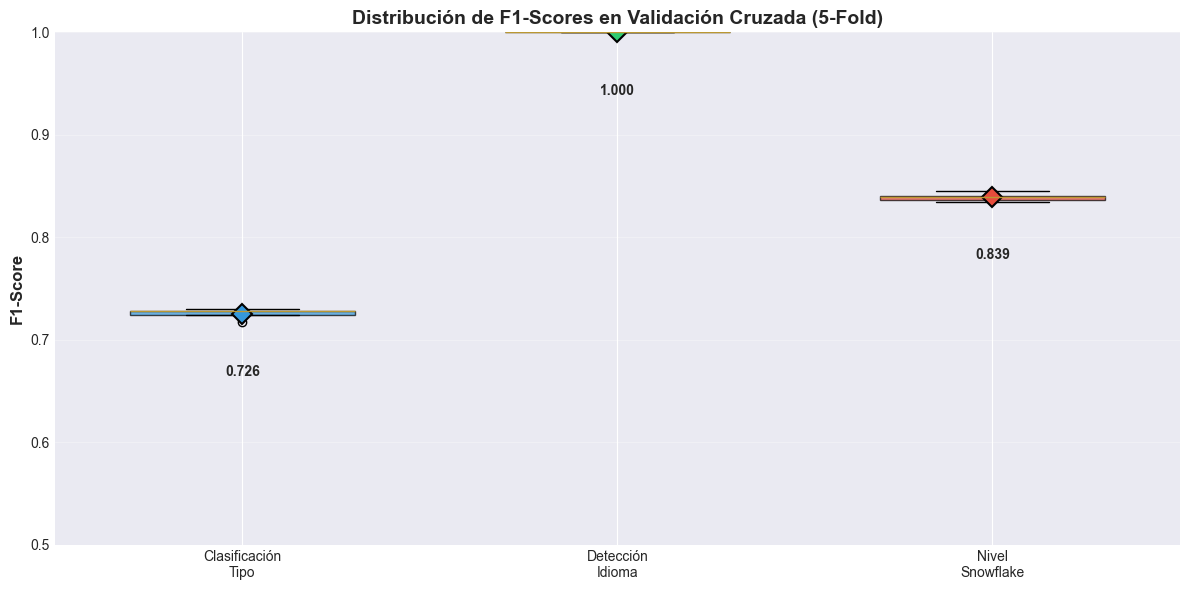


RESUMEN DE VALIDACIÓN CRUZADA

Tarea                     Modelo                    CV Mean         CV Std         
--------------------------------------------------------------------------------
Clasificación Tipo        Random Forest             0.7255          0.0047
Detección Idioma          Naive Bayes               1.0000          0.0000
Nivel Snowflake           Gradient Boosting         0.8392          0.0036


In [26]:
# Validación cruzada para los mejores modelos de cada tarea
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configurar KFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 80)
print("VALIDACIÓN CRUZADA - EVALUACIÓN DE ROBUSTEZ")
print("=" * 80)

# Tarea 1: Tipo de Ticket
print("\n📋 TAREA 1: CLASIFICACIÓN DE TIPO")
print("-" * 80)
model_type = results_type[best_type]['model']
# Determinar si necesita escalado
if best_type in ['Logistic Regression', 'SVM', 'Gradient Boosting']:
    cv_scores_type = cross_val_score(model_type, X_train_scaled, y_type_train, cv=kfold, scoring='f1_weighted', n_jobs=-1)
else:
    cv_scores_type = cross_val_score(model_type, X_train, y_type_train, cv=kfold, scoring='f1_weighted', n_jobs=-1)

print(f"Modelo: {best_type}")
print(f"F1-Score CV promedio: {cv_scores_type.mean():.4f} (+/- {cv_scores_type.std():.4f})")
print(f"Scores por fold: {[f'{s:.4f}' for s in cv_scores_type]}")

# Tarea 2: Idioma
print("\n🌍 TAREA 2: DETECCIÓN DE IDIOMA")
print("-" * 80)
model_lang = results_language[best_lang]['model']
if best_lang in ['Logistic Regression', 'SVM', 'Gradient Boosting']:
    cv_scores_lang = cross_val_score(model_lang, X_train_scaled, y_lang_train, cv=kfold, scoring='f1_weighted', n_jobs=-1)
else:
    cv_scores_lang = cross_val_score(model_lang, X_train, y_lang_train, cv=kfold, scoring='f1_weighted', n_jobs=-1)

print(f"Modelo: {best_lang}")
print(f"F1-Score CV promedio: {cv_scores_lang.mean():.4f} (+/- {cv_scores_lang.std():.4f})")
print(f"Scores por fold: {[f'{s:.4f}' for s in cv_scores_lang]}")

# Tarea 3: Nivel Snowflake
print("\n🏢 TAREA 3: NIVEL SNOWFLAKE DW")
print("-" * 80)
model_snow = results_snowflake[best_snow]['model']
if best_snow in ['Logistic Regression', 'SVM', 'Gradient Boosting']:
    cv_scores_snow = cross_val_score(model_snow, X_train_scaled, y_snow_train, cv=kfold, scoring='f1_weighted', n_jobs=-1)
else:
    cv_scores_snow = cross_val_score(model_snow, X_train, y_snow_train, cv=kfold, scoring='f1_weighted', n_jobs=-1)

print(f"Modelo: {best_snow}")
print(f"F1-Score CV promedio: {cv_scores_snow.mean():.4f} (+/- {cv_scores_snow.std():.4f})")
print(f"Scores por fold: {[f'{s:.4f}' for s in cv_scores_snow]}")

# Visualización comparativa
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

cv_data = {
    'Tarea': ['Clasificación\nTipo'] * 5 + ['Detección\nIdioma'] * 5 + ['Nivel\nSnowflake'] * 5,
    'Fold': list(range(1, 6)) * 3,
    'F1-Score': list(cv_scores_type) + list(cv_scores_lang) + list(cv_scores_snow)
}

df_cv = pd.DataFrame(cv_data)

positions = [1, 2, 3]
bp = ax.boxplot([cv_scores_type, cv_scores_lang, cv_scores_snow], 
                 positions=positions,
                 widths=0.6,
                 patch_artist=True,
                 labels=['Clasificación\nTipo', 'Detección\nIdioma', 'Nivel\nSnowflake'])

colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Distribución de F1-Scores en Validación Cruzada (5-Fold)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Añadir medias
for i, scores in enumerate([cv_scores_type, cv_scores_lang, cv_scores_snow]):
    mean_score = scores.mean()
    ax.plot(i + 1, mean_score, 'D', color=colors[i], markersize=10, markeredgecolor='black', markeredgewidth=1.5)
    ax.text(i + 1, mean_score - 0.05, f'{mean_score:.3f}', ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("RESUMEN DE VALIDACIÓN CRUZADA")
print("=" * 80)
print(f"\n{'Tarea':<25} {'Modelo':<25} {'CV Mean':<15} {'CV Std':<15}")
print("-" * 80)
print(f"{'Clasificación Tipo':<25} {best_type:<25} {cv_scores_type.mean():.4f}          {cv_scores_type.std():.4f}")
print(f"{'Detección Idioma':<25} {best_lang:<25} {cv_scores_lang.mean():.4f}          {cv_scores_lang.std():.4f}")
print(f"{'Nivel Snowflake':<25} {best_snow:<25} {cv_scores_snow.mean():.4f}          {cv_scores_snow.std():.4f}")

## 6. Cross-Validation

Aplicaremos validación cruzada para obtener una evaluación más robusta del rendimiento de los modelos.

In [29]:
import time
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_lock = threading.Lock()

SCALED_MODELS_CV = {'Logistic Regression', 'SVM (Linear)'}

tasks_cv = [
    ('type',      '📋 Tipo de Ticket',  y_type_train),
    ('language',  '🌍 Idioma',           y_lang_train),
    ('snowflake', '🏢 Nivel Snowflake',  y_snow_train),
]

raw_cv = {}   # {task_key: {model_name: scores_array}}


def cv_job(model_name, model_template, task_key, X_cv, y_tr):
    """Ejecuta 5-fold CV para un modelo+tarea."""
    # n_jobs=1 por job porque ya paralelizamos a nivel externo
    scores = cross_val_score(clone(model_template), X_cv, y_tr,
                             cv=cv, scoring='accuracy', n_jobs=1)
    return model_name, task_key, scores


# Preparar todos los jobs (5 modelos × 3 tareas = 15 threads simultáneos)
cv_jobs_list = []
for task_key, task_label, y_tr in tasks_cv:
    for name, model_template in models.items():
        X_cv = X_train_scaled if name in SCALED_MODELS_CV else X_train
        cv_jobs_list.append((name, model_template, task_key, X_cv, y_tr))

total_cv = len(cv_jobs_list)

print("\n" + "="*80)
print("VALIDACIÓN CRUZADA (5-FOLD) — MULTI-OBJETIVO, MÁXIMO PARALELISMO")
print(f"🚀 Lanzando {len(models)} modelos × 3 tareas = {total_cv} threads simultáneos")
print("="*80 + "\n")

t_cv_start = time.time()
completed_cv = 0

with ThreadPoolExecutor(max_workers=total_cv) as executor:
    futures_cv = {executor.submit(cv_job, *job): job for job in cv_jobs_list}

    for future in as_completed(futures_cv):
        model_name, task_key, scores = future.result()

        with cv_lock:
            if task_key not in raw_cv:
                raw_cv[task_key] = {}
            raw_cv[task_key][model_name] = scores
            completed_cv += 1
            print(f"   ✅ [{completed_cv:>2}/{total_cv}] {model_name} — {task_key}: "
                  f"{scores.mean():.4f} ± {scores.std():.4f}")

t_cv_total = time.time() - t_cv_start

# Construir comparison_dfs para celdas posteriores de análisis
task_meta_cv = [
    ('type',      '📋 Tipo de Ticket',  results_type,      y_type_test),
    ('language',  '🌍 Idioma',           results_language,  y_lang_test),
    ('snowflake', '🏢 Nivel Snowflake',  results_snowflake, y_snow_test),
]

comparison_dfs = {}

print("\n\n" + "="*80)
print("RESUMEN: TEST ACCURACY VS CV MEAN")
print("="*80)

for task_key, task_label, results_dict, y_te in task_meta_cv:
    rows = []
    for name in models.keys():
        sc = raw_cv[task_key][name]
        rows.append({
            'Modelo':   name,
            'Test Acc': round(accuracy_score(y_te, results_dict[name]['y_test_pred']), 4),
            'CV Mean':  round(sc.mean(), 4),
            'CV Std':   round(sc.std(),  4),
            'CV Min':   round(sc.min(),  4),
            'CV Max':   round(sc.max(),  4),
        })
    cv_df = pd.DataFrame(rows)
    cv_df['Diff (Test-CV)'] = (cv_df['Test Acc'] - cv_df['CV Mean']).round(4)
    comparison_dfs[task_key] = cv_df

    print(f"\n{task_label}")
    print(cv_df[['Modelo', 'Test Acc', 'CV Mean', 'CV Std', 'Diff (Test-CV)']].to_string(index=False))

print(f"\n⏱️  Tiempo total CV: {t_cv_total:.1f}s  ({total_cv} threads simultáneos)")


VALIDACIÓN CRUZADA (5-FOLD) — MULTI-OBJETIVO, MÁXIMO PARALELISMO
🚀 Lanzando 5 modelos × 3 tareas = 15 threads simultáneos

   ✅ [ 1/15] Naive Bayes — snowflake: 0.6229 ± 0.0038
   ✅ [ 2/15] Naive Bayes — type: 0.5607 ± 0.0034
   ✅ [ 3/15] Naive Bayes — language: 1.0000 ± 0.0000
   ✅ [ 4/15] SVM (Linear) — snowflake: 0.7959 ± 0.0034
   ✅ [ 5/15] SVM (Linear) — type: 0.6867 ± 0.0022
   ✅ [ 6/15] SVM (Linear) — language: 0.9910 ± 0.0005
   ✅ [ 7/15] Random Forest — language: 0.9910 ± 0.0027
   ✅ [ 8/15] Random Forest — snowflake: 0.8297 ± 0.0036
   ✅ [ 9/15] Random Forest — type: 0.7209 ± 0.0049
   ✅ [10/15] Logistic Regression — language: 0.9999 ± 0.0001
   ✅ [11/15] Logistic Regression — type: 0.6454 ± 0.0047
   ✅ [12/15] Logistic Regression — snowflake: 0.7887 ± 0.0016
   ✅ [13/15] Gradient Boosting — language: 1.0000 ± 0.0000
   ✅ [14/15] Gradient Boosting — snowflake: 0.8392 ± 0.0041
   ✅ [15/15] Gradient Boosting — type: 0.7312 ± 0.0022


RESUMEN: TEST ACCURACY VS CV MEAN

📋 Tipo d

### 6.1 Visualización de Cross-Validation

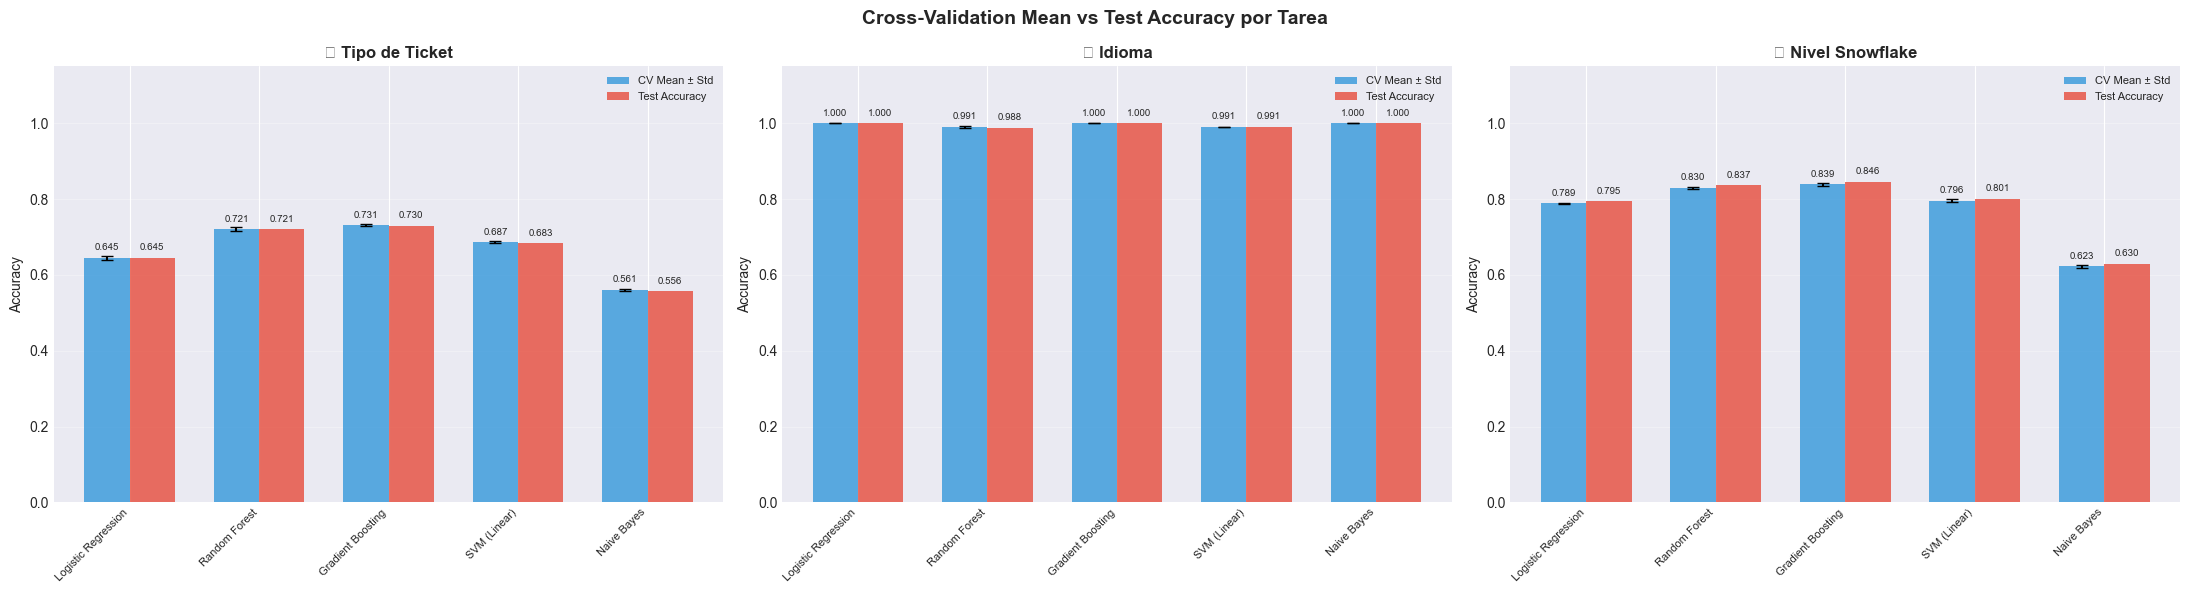

In [30]:
# Gráfico CV Mean vs Test Accuracy para las 3 tareas
task_plot_meta = [
    ('type',      '📋 Tipo de Ticket',  results_type,      y_type_test),
    ('language',  '🌍 Idioma',           results_language,  y_lang_test),
    ('snowflake', '🏢 Nivel Snowflake',  results_snowflake, y_snow_test),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Cross-Validation Mean vs Test Accuracy por Tarea', fontsize=14, fontweight='bold')

for ax, (task_key, task_label, results_dict, y_te) in zip(axes, task_plot_meta):
    cv_df = comparison_dfs[task_key]
    x = np.arange(len(cv_df))
    width = 0.35

    ax.bar(x - width/2, cv_df['CV Mean'], width,
           yerr=cv_df['CV Std'], capsize=4, label='CV Mean ± Std',
           color='#3498db', alpha=0.8, error_kw={'linewidth': 1.5})
    ax.bar(x + width/2, cv_df['Test Acc'], width,
           label='Test Accuracy', color='#e74c3c', alpha=0.8)
    ax.set_title(task_label, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cv_df['Modelo'], rotation=45, ha='right', fontsize=8)
    ax.set_ylim([0, 1.15])
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for i, (cv_m, te_a) in enumerate(zip(cv_df['CV Mean'], cv_df['Test Acc'])):
        ax.text(i - width/2, cv_m + 0.02, f'{cv_m:.3f}', ha='center', fontsize=7)
        ax.text(i + width/2, te_a + 0.02, f'{te_a:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

**Interpretación:**

- **Baja desviación estándar:** Indica que el modelo es consistente entre diferentes particiones de datos
- **CV Mean similar a Test Accuracy:** Sugiere que el modelo generaliza bien
- **Gran diferencia entre CV y Test:** Puede indicar problemas de generalización o partición desafortunada

## 7. Interpretación y Conclusiones

### 7.1 Análisis de Diferencias entre Train, Test y Cross-Validation

In [31]:
# Resumen final: train, test y CV para las 3 tareas
print("\n" + "="*80)
print("ANÁLISIS DE SOBREAJUSTE POR TAREA")
print("="*80)

task_final_meta = [
    ('type',      '📋 Tipo de Ticket',  results_type,      y_type_train, y_type_test),
    ('language',  '🌍 Idioma',           results_language,  y_lang_train, y_lang_test),
    ('snowflake', '🏢 Nivel Snowflake',  results_snowflake, y_snow_train, y_snow_test),
]

for task_key, task_label, results_dict, y_tr, y_te in task_final_meta:
    cv_df = comparison_dfs[task_key]
    print(f"\n{task_label}")
    print(f"{'-'*80}")
    for model_name in models.keys():
        train_acc = accuracy_score(y_tr, results_dict[model_name]['y_train_pred'])
        test_acc  = accuracy_score(y_te, results_dict[model_name]['y_test_pred'])
        cv_row    = cv_df[cv_df['Modelo'] == model_name].iloc[0]
        gap       = train_acc - test_acc
        print(f"\n  📊 {model_name}:")
        print(f"     Train: {train_acc:.4f}  |  Test: {test_acc:.4f}  |  CV: {cv_row['CV Mean']:.4f} ± {cv_row['CV Std']:.4f}")
        print(f"     Overfitting gap: {gap:.4f}", end='  ')
        if gap > 0.1:
            print("⚠️  ALTO SOBREAJUSTE")
        elif gap > 0.05:
            print("⚡ SOBREAJUSTE MODERADO")
        else:
            print("✓ BUEN EQUILIBRIO")


ANÁLISIS DE SOBREAJUSTE POR TAREA

📋 Tipo de Ticket
--------------------------------------------------------------------------------

  📊 Logistic Regression:
     Train: 0.6487  |  Test: 0.6447  |  CV: 0.6454 ± 0.0047
     Overfitting gap: 0.0040  ✓ BUEN EQUILIBRIO

  📊 Random Forest:
     Train: 0.8570  |  Test: 0.7210  |  CV: 0.7209 ± 0.0049
     Overfitting gap: 0.1360  ⚠️  ALTO SOBREAJUSTE

  📊 Gradient Boosting:
     Train: 0.7666  |  Test: 0.7301  |  CV: 0.7312 ± 0.0022
     Overfitting gap: 0.0365  ✓ BUEN EQUILIBRIO

  📊 SVM (Linear):
     Train: 0.6898  |  Test: 0.6834  |  CV: 0.6867 ± 0.0022
     Overfitting gap: 0.0064  ✓ BUEN EQUILIBRIO

  📊 Naive Bayes:
     Train: 0.5613  |  Test: 0.5565  |  CV: 0.5607 ± 0.0034
     Overfitting gap: 0.0049  ✓ BUEN EQUILIBRIO

🌍 Idioma
--------------------------------------------------------------------------------

  📊 Logistic Regression:
     Train: 1.0000  |  Test: 0.9999  |  CV: 0.9999 ± 0.0001
     Overfitting gap: 0.0001  ✓ BUEN EQ

### 7.2 Análisis de Importancia de Features (para modelos aplicables)


TOP 20 FEATURES MÁS IMPORTANTES (Random Forest)

         Feature  Importance
        tfidf_60    0.077771
        tfidf_45    0.075961
        tfidf_64    0.029619
        tfidf_41    0.026551
        tfidf_46    0.026112
        tfidf_31    0.025928
        tfidf_21    0.025783
        tfidf_76    0.022161
        tfidf_13    0.021427
        tfidf_67    0.021255
priority_encoded    0.019505
        tfidf_74    0.019248
        tfidf_65    0.019154
     body_length    0.018825
   queue_encoded    0.018567
     text_length    0.016865
      word_count    0.015885
        tfidf_36    0.015507
        tfidf_62    0.014069
        tfidf_72    0.013995



TOP 20 FEATURES MÁS IMPORTANTES (Random Forest)

         Feature  Importance
        tfidf_60    0.077771
        tfidf_45    0.075961
        tfidf_64    0.029619
        tfidf_41    0.026551
        tfidf_46    0.026112
        tfidf_31    0.025928
        tfidf_21    0.025783
        tfidf_76    0.022161
        tfidf_13    0.021427
        tfidf_67    0.021255
priority_encoded    0.019505
        tfidf_74    0.019248
        tfidf_65    0.019154
     body_length    0.018825
   queue_encoded    0.018567
     text_length    0.016865
      word_count    0.015885
        tfidf_36    0.015507
        tfidf_62    0.014069
        tfidf_72    0.013995


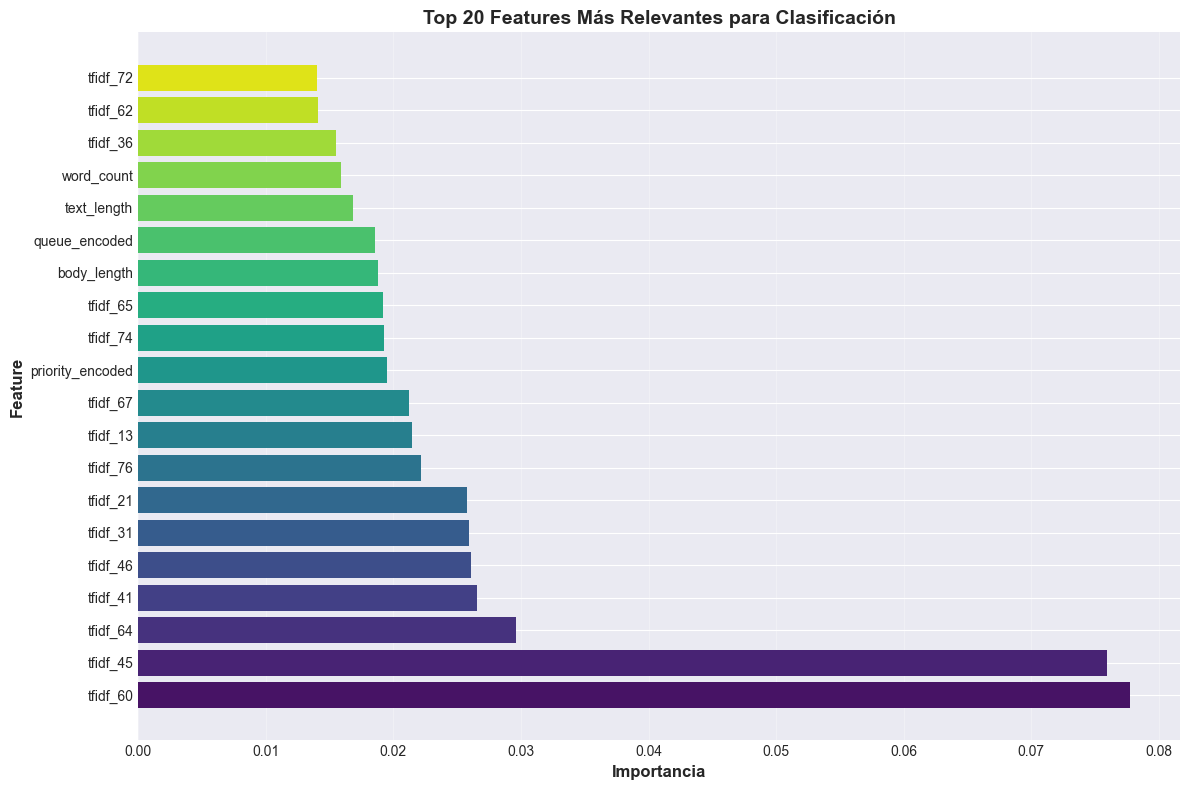


✓ Análisis de importancia de features completado


In [32]:
# Extraer importancia de features para Random Forest (tarea: tipo de ticket)
if 'Random Forest' in results_type:
    rf_model = results_type['Random Forest']['model']
    
    # Obtener importancias
    feature_names = feature_cols + [f'tfidf_{i}' for i in range(text_features.shape[1])]
    importances = rf_model.feature_importances_
    
    # Crear dataframe de importancias
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(20)
    
    print("\n" + "="*80)
    print("TOP 20 FEATURES MÁS IMPORTANTES (Random Forest)")
    print("="*80 + "\n")
    print(feature_importance_df.to_string(index=False))
    
    # Visualización
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
             color=sns.color_palette("viridis", len(feature_importance_df)))
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12, fontweight='bold')
    plt.title('Top 20 Features Más Relevantes para Clasificación', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✓ Análisis de importancia de features completado")

## 9. Resumen Final y Persistencia de Modelos

Guardaremos los mejores modelos entrenados y crearemos un resumen ejecutivo del proyecto.

### 7.3 Ranking Final de Modelos

In [35]:
import pickle
import joblib
from datetime import datetime

# Crear directorio para modelos
models_dir = '../model_artifacts'
os.makedirs(models_dir, exist_ok=True)

# Guardar los mejores modelos
print("=" * 80)
print("GUARDANDO MODELOS ENTRENADOS")
print("=" * 80 + "\n")

# ── Nombres FIJOS (sin timestamp) para que TicketClassifier los encuentre ──
model_type_path = os.path.join(models_dir, 'model_type_random_forest.pkl')
model_lang_path = os.path.join(models_dir, 'model_language_naive_bayes.pkl')
model_snow_path = os.path.join(models_dir, 'model_snowflake_gradient_boosting.pkl')
scaler_path     = os.path.join(models_dir, 'scaler.pkl')
le_path         = os.path.join(models_dir, 'label_encoders.pkl')
tfidf_path      = os.path.join(models_dir, 'tfidf_vectorizer.pkl')
metadata_path   = os.path.join(models_dir, 'model_metadata.pkl')

joblib.dump(results_type['Random Forest']['model'],      model_type_path)
print(f"✅ Modelo Tipo guardado:      {model_type_path}")

joblib.dump(results_language['Naive Bayes']['model'],    model_lang_path)
print(f"✅ Modelo Idioma guardado:    {model_lang_path}")

joblib.dump(results_snowflake['Gradient Boosting']['model'], model_snow_path)
print(f"✅ Modelo Snowflake guardado: {model_snow_path}")

joblib.dump(scaler, scaler_path)
print(f"✅ Scaler guardado:           {scaler_path}")

joblib.dump(label_encoders, le_path)
print(f"✅ Label Encoders guardados:  {le_path}")

# TF-IDF vectorizer — necesario para que TicketClassifier pueda preprocesar
joblib.dump(tfidf, tfidf_path)
print(f"✅ TF-IDF vectorizer guardado:{tfidf_path}")

# Guardar metadata del modelo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
metadata = {
    'best_models': {
        'type':      'Random Forest',
        'language':  'Naive Bayes',
        'snowflake': 'Gradient Boosting',
    },
    'performance': {
        'type': {
            'accuracy': accuracy_score(y_type_test, y_pred_type),
            'f1_score': f1_score(y_type_test, y_pred_type, average='weighted'),
            'cv_mean':  cv_scores_type.mean(),
            'cv_std':   cv_scores_type.std()
        },
        'language': {
            'accuracy': accuracy_score(y_lang_test, y_pred_lang),
            'f1_score': f1_score(y_lang_test, y_pred_lang, average='weighted'),
            'cv_mean':  cv_scores_lang.mean(),
            'cv_std':   cv_scores_lang.std()
        },
        'snowflake': {
            'accuracy': accuracy_score(y_snow_test, y_pred_snow),
            'f1_score': f1_score(y_snow_test, y_pred_snow, average='weighted'),
            'cv_mean':  cv_scores_snow.mean(),
            'cv_std':   cv_scores_snow.std()
        }
    },
    'features': {
        'total_features':       X_train.shape[1],
        'tfidf_max_features':   tfidf.max_features,
        'feature_names':        feature_cols if 'feature_cols' in locals() else list(df_ml.columns)
    },
    'dataset': {
        'total_samples':  len(df),
        'train_samples':  len(X_train),
        'test_samples':   len(X_test),
        'languages':      list(df[language_col].unique()) if language_col in df.columns else [],
        'snowflake_level': SNOWFLAKE_LEVEL
    },
    'training_date': timestamp,
    'model_files': {
        'type':           'model_type_random_forest.pkl',
        'language':       'model_language_naive_bayes.pkl',
        'snowflake':      'model_snowflake_gradient_boosting.pkl',
        'scaler':         'scaler.pkl',
        'label_encoders': 'label_encoders.pkl',
        'tfidf':          'tfidf_vectorizer.pkl',
        'metadata':       'model_metadata.pkl',
    }
}

with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✅ Metadata guardada:         {metadata_path}")

# Resumen ejecutivo
print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO DEL PROYECTO")
print("=" * 80)
print(f"\n🎯 PROYECTO: Sistema de Clasificación Inteligente de Tickets IceBergTicket")
print(f"📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n" + "-" * 80)
print("DATOS DEL DATASET")
print("-" * 80)
print(f"Total de registros:           {len(df):,}")
print(f"Conjunto de entrenamiento:    {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Conjunto de prueba:           {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")
print(f"Total de características:     {X_train.shape[1]}")
print(f"Idiomas detectados:           {', '.join(metadata['dataset']['languages'])}")
print(f"Nivel Snowflake DW:           {SNOWFLAKE_LEVEL}")

print("\n" + "-" * 80)
print("MODELOS SELECCIONADOS")
print("-" * 80)
print(f"📋 Clasificación de Tipo:     Random Forest")
print(f"🌍 Detección de Idioma:       Naive Bayes")
print(f"🏢 Nivel Snowflake DW:        Gradient Boosting")

print("\n" + "-" * 80)
print("RENDIMIENTO EN TEST SET")
print("-" * 80)
for task, label in [('type', '📋 Tipo de Ticket'), ('language', '🌍 Idioma'), ('snowflake', '🏢 Nivel Snowflake')]:
    p = metadata['performance'][task]
    print(f"\n{label}:")
    print(f"   Accuracy: {p['accuracy']:.4f}  |  F1: {p['f1_score']:.4f}  |  CV: {p['cv_mean']:.4f} ± {p['cv_std']:.4f}")

print("\n" + "-" * 80)
print("ARCHIVOS GENERADOS")
print("-" * 80)
for key, fname in metadata['model_files'].items():
    print(f"• {key:<16} {fname}")

print("\n" + "=" * 80)
print("✅ PROYECTO COMPLETADO EXITOSAMENTE")
print("=" * 80)


GUARDANDO MODELOS ENTRENADOS

✅ Modelo Tipo guardado:      ../model_artifacts\model_type_random_forest.pkl
✅ Modelo Idioma guardado:    ../model_artifacts\model_language_naive_bayes.pkl
✅ Modelo Snowflake guardado: ../model_artifacts\model_snowflake_gradient_boosting.pkl
✅ Scaler guardado:           ../model_artifacts\scaler.pkl
✅ Label Encoders guardados:  ../model_artifacts\label_encoders.pkl
✅ TF-IDF vectorizer guardado:../model_artifacts\tfidf_vectorizer.pkl
✅ Metadata guardada:         ../model_artifacts\model_metadata.pkl

RESUMEN EJECUTIVO DEL PROYECTO

🎯 PROYECTO: Sistema de Clasificación Inteligente de Tickets IceBergTicket
📅 Fecha: 2026-03-10 01:08:43

--------------------------------------------------------------------------------
DATOS DEL DATASET
--------------------------------------------------------------------------------
Total de registros:           67,890
Conjunto de entrenamiento:    54,312 (80.0%)
Conjunto de prueba:           13,578 (20.0%)
Total de característic

## 8. Generación de Esquemas Snowflake Data Warehouse

Basándose en el nivel determinado, generaremos el esquema SQL apropiado para el Data Warehouse.

In [ ]:

# Función para generar esquema SQL basado en el nivel y perfil real de datos
def generate_snowflake_schema(level, dataset_columns, data_profile=None):
    """
    Genera el esquema SQL adaptado al nivel y al perfil real de datos
    de la división estratégica.
    """
    has_tags = any(col.startswith('tag_') for col in dataset_columns)
    has_product = 'product' in dataset_columns or 'version' in dataset_columns
    has_priority = 'priority' in dataset_columns
    has_queue = 'queue' in dataset_columns
    has_language = 'language' in dataset_columns

    p = data_profile or {}
    n_tickets = p.get('n_tickets', 0)
    n_languages = p.get('n_languages', 0)
    languages_list = p.get('languages', [])
    n_types = p.get('n_types', 0)
    types_list = p.get('types', [])
    avg_text_length = p.get('avg_text_length', 0)
    priorities_list = p.get('priorities', [])
    avg_tags = p.get('avg_tags', 0)

    lang_map = {'en': 'English', 'es': 'Español', 'de': 'Deutsch', 'fr': 'Français', 'pt': 'Português'}

    schema = f"""
-- ============================================================================
-- ESQUEMA DATA WAREHOUSE SNOWFLAKE - NIVEL {level}
-- Generado por IceBergTicket ML System (División Estratégica)
-- Fecha: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
-- ============================================================================
-- PERFIL DE DATOS REAL:
--   Tickets asignados a este esquema: {n_tickets:,}
--   Idiomas: {n_languages} ({', '.join(languages_list)})
--   Tipos de ticket: {n_types} ({', '.join(types_list)})
--   Prioridades: {', '.join(priorities_list)}
--   Long. media texto: {avg_text_length:.0f} chars
--   Tags promedio/ticket: {avg_tags:.1f}
-- ============================================================================
"""

    if level == 'BASIC':
        schema += f"""
-- NIVEL BÁSICO: {n_tickets:,} tickets simples
-- Tickets con baja complejidad: pocas tags, textos cortos

CREATE SCHEMA IF NOT EXISTS tickets_basic;
USE SCHEMA tickets_basic;

CREATE OR REPLACE TABLE fact_tickets (
    ticket_id INT PRIMARY KEY,
    date_key INT, customer_key INT, agent_key INT,
    priority_key INT, status_key INT,
    submitter_email VARCHAR(255), submitter_name VARCHAR(255),
    created_at TIMESTAMP, resolved_at TIMESTAMP, closed_at TIMESTAMP,
    resolution_time_hours DECIMAL(8,2), first_response_hours DECIMAL(8,2),
    FOREIGN KEY (date_key) REFERENCES dim_date(date_key),
    FOREIGN KEY (customer_key) REFERENCES dim_customer(customer_key),
    FOREIGN KEY (agent_key) REFERENCES dim_agent(agent_key),
    FOREIGN KEY (priority_key) REFERENCES dim_priority(priority_key),
    FOREIGN KEY (status_key) REFERENCES dim_status(status_key)
);

CREATE OR REPLACE TABLE dim_date (
    date_key INT PRIMARY KEY, date DATE, year INT, month INT,
    month_name VARCHAR(20), day INT, day_name VARCHAR(20), is_weekend BOOLEAN
);

CREATE OR REPLACE TABLE dim_customer (
    customer_key INT PRIMARY KEY, customer_name VARCHAR(255),
    email VARCHAR(255), created_at TIMESTAMP
);

CREATE OR REPLACE TABLE dim_agent (
    agent_key INT PRIMARY KEY, agent_name VARCHAR(255),
    email VARCHAR(255), team VARCHAR(100)
);

CREATE OR REPLACE TABLE dim_priority (
    priority_key INT PRIMARY KEY, priority_name VARCHAR(50), level INT
);

CREATE OR REPLACE TABLE dim_status (
    status_key INT PRIMARY KEY, status_name VARCHAR(50), category VARCHAR(50)
);

CREATE OR REPLACE TABLE ticket_text (
    ticket_id INT PRIMARY KEY, subject TEXT, description TEXT, solution TEXT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id)
);

CREATE INDEX idx_tickets_date ON fact_tickets(date_key);
CREATE INDEX idx_tickets_customer ON fact_tickets(customer_key);
CREATE INDEX idx_tickets_created ON fact_tickets(created_at);
"""
        for i, prio in enumerate(priorities_list, 1):
            schema += f"INSERT INTO dim_priority VALUES ({i}, '{prio}', {i});\n"

        if n_languages > 1:
            schema += f"\n-- ⚠️ {n_languages} idiomas detectados pero BASIC no incluye dim_language\n"
            schema += "-- Considerar upgrade a MEDIUM si soporte multiidioma es requerido\n"

        schema += f"\nCOMMENT ON TABLE fact_tickets IS 'BASIC: {n_tickets:,} tickets simples';\n"

    elif level == 'MEDIUM':
        schema += f"""
-- NIVEL MEDIUM: {n_tickets:,} tickets de complejidad intermedia
-- Incluye multiidioma, productos, segmentación, SLAs

CREATE SCHEMA IF NOT EXISTS tickets_medium;
USE SCHEMA tickets_medium;

CREATE OR REPLACE TABLE fact_tickets (
    ticket_id INT PRIMARY KEY,
    date_key INT, customer_key INT, agent_key INT,
    type_key INT, priority_key INT, status_key INT,
    category_key INT, product_key INT, language_key INT, channel_key INT,
    submitter_user_id VARCHAR(100), submitter_email VARCHAR(255), submitter_name VARCHAR(255),
    created_at TIMESTAMP, resolved_at TIMESTAMP, closed_at TIMESTAMP,
    resolution_time_hours DECIMAL(10,2), first_response_hours DECIMAL(10,2),
    sla_breached BOOLEAN, response_count INT, satisfaction_score DECIMAL(3,2),
    FOREIGN KEY (date_key) REFERENCES dim_date(date_key),
    FOREIGN KEY (customer_key) REFERENCES dim_customer(customer_key),
    FOREIGN KEY (agent_key) REFERENCES dim_agent(agent_key),
    FOREIGN KEY (type_key) REFERENCES dim_type(type_key),
    FOREIGN KEY (priority_key) REFERENCES dim_priority(priority_key),
    FOREIGN KEY (status_key) REFERENCES dim_status(status_key),
    FOREIGN KEY (category_key) REFERENCES dim_category(category_key),
    FOREIGN KEY (product_key) REFERENCES dim_product(product_key),
    FOREIGN KEY (language_key) REFERENCES dim_language(language_key),
    FOREIGN KEY (channel_key) REFERENCES dim_channel(channel_key)
);

CREATE OR REPLACE TABLE dim_date (
    date_key INT PRIMARY KEY, date DATE, year INT, quarter INT,
    month INT, month_name VARCHAR(20), week INT, day INT,
    day_name VARCHAR(20), is_weekend BOOLEAN, is_holiday BOOLEAN
);

CREATE OR REPLACE TABLE dim_customer (
    customer_key INT PRIMARY KEY, customer_name VARCHAR(255), email VARCHAR(255),
    segment_key INT, location VARCHAR(100), account_type VARCHAR(50),
    FOREIGN KEY (segment_key) REFERENCES dim_customer_segment(segment_key)
);

CREATE OR REPLACE TABLE dim_customer_segment (
    segment_key INT PRIMARY KEY, segment_name VARCHAR(100), segment_description TEXT
);

CREATE OR REPLACE TABLE dim_agent (
    agent_key INT PRIMARY KEY, agent_name VARCHAR(255), email VARCHAR(255),
    team_key INT, skill_level VARCHAR(50),
    FOREIGN KEY (team_key) REFERENCES dim_team(team_key)
);

CREATE OR REPLACE TABLE dim_team (
    team_key INT PRIMARY KEY, team_name VARCHAR(100),
    manager_name VARCHAR(255), department VARCHAR(100)
);

CREATE OR REPLACE TABLE dim_type (
    type_key INT PRIMARY KEY, type_name VARCHAR(100), type_description TEXT
);

CREATE OR REPLACE TABLE dim_priority (
    priority_key INT PRIMARY KEY, priority_name VARCHAR(50), level INT, sla_hours INT
);

CREATE OR REPLACE TABLE dim_status (
    status_key INT PRIMARY KEY, status_name VARCHAR(50),
    category VARCHAR(50), is_final BOOLEAN
);

CREATE OR REPLACE TABLE dim_category (
    category_key INT PRIMARY KEY, category_name VARCHAR(100), department VARCHAR(100)
);

CREATE OR REPLACE TABLE dim_product (
    product_key INT PRIMARY KEY, product_name VARCHAR(255),
    version VARCHAR(50), release_date DATE
);

CREATE OR REPLACE TABLE dim_language (
    language_key INT PRIMARY KEY, language_code VARCHAR(5), language_name VARCHAR(50)
);

CREATE OR REPLACE TABLE dim_channel (
    channel_key INT PRIMARY KEY, channel_name VARCHAR(100), channel_type VARCHAR(50)
);

CREATE OR REPLACE TABLE ticket_text (
    ticket_id INT PRIMARY KEY, subject TEXT, description TEXT, solution TEXT, internal_notes TEXT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id)
);

CREATE OR REPLACE TABLE fact_status_history (
    history_id INT PRIMARY KEY, ticket_id INT, status_key INT, agent_key INT,
    changed_at TIMESTAMP, duration_minutes INT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id),
    FOREIGN KEY (status_key) REFERENCES dim_status(status_key)
);

CREATE INDEX idx_tickets_date ON fact_tickets(date_key);
CREATE INDEX idx_tickets_type ON fact_tickets(type_key);
CREATE INDEX idx_tickets_priority ON fact_tickets(priority_key);
CREATE INDEX idx_tickets_language ON fact_tickets(language_key);
CREATE INDEX idx_tickets_created ON fact_tickets(created_at);
"""
        for i, lang in enumerate(languages_list, 1):
            schema += f"INSERT INTO dim_language VALUES ({i}, '{lang}', '{lang_map.get(lang, lang)}');\n"
        for i, t in enumerate(types_list, 1):
            schema += f"INSERT INTO dim_type VALUES ({i}, '{t}', 'Tickets {t}');\n"
        for i, prio in enumerate(priorities_list, 1):
            sla = 24 * (len(priorities_list) - i + 1)
            schema += f"INSERT INTO dim_priority VALUES ({i}, '{prio}', {i}, {sla});\n"

        schema += f"""
CREATE OR REPLACE VIEW v_ticket_summary AS
SELECT f.ticket_id, d.date, c.customer_name, a.agent_name,
       t.type_name, p.priority_name, s.status_name, l.language_name,
       f.resolution_time_hours, f.satisfaction_score
FROM fact_tickets f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_customer c ON f.customer_key = c.customer_key
JOIN dim_agent a ON f.agent_key = a.agent_key
JOIN dim_type t ON f.type_key = t.type_key
JOIN dim_priority p ON f.priority_key = p.priority_key
JOIN dim_status s ON f.status_key = s.status_key
JOIN dim_language l ON f.language_key = l.language_key;

COMMENT ON TABLE fact_tickets IS 'MEDIUM: {n_tickets:,} tickets intermedios';
COMMENT ON TABLE dim_language IS '{n_languages} idiomas: {", ".join(languages_list)}';
"""

    else:  # PRO
        schema += f"""
-- NIVEL PRO: {n_tickets:,} tickets complejos
-- Normalización completa, bridge tables, jerarquías, análisis avanzado
-- Tags promedio: {avg_tags:.1f}/ticket | Texto medio: {avg_text_length:.0f} chars

CREATE SCHEMA IF NOT EXISTS tickets_pro;
USE SCHEMA tickets_pro;

CREATE OR REPLACE TABLE fact_tickets (
    ticket_id BIGINT PRIMARY KEY,
    date_key INT, time_key INT, customer_key INT,
    submitter_user_id VARCHAR(100), submitter_email VARCHAR(255), submitter_name VARCHAR(255),
    agent_key INT, type_key INT, priority_key INT, queue_key INT,
    language_key INT, status_key INT, category_key INT,
    product_key INT, channel_key INT, sla_key INT,
    created_at TIMESTAMP, resolved_at TIMESTAMP, closed_at TIMESTAMP,
    first_response_time_minutes DECIMAL(10,2), resolution_time_minutes DECIMAL(10,2),
    response_count INT, reopened_count INT,
    escalated_flag BOOLEAN, satisfaction_score DECIMAL(3,2),
    sentiment_score DECIMAL(3,2), word_count_subject INT, word_count_body INT,
    sla_breached_flag BOOLEAN,
    FOREIGN KEY (date_key) REFERENCES dim_date(date_key),
    FOREIGN KEY (time_key) REFERENCES dim_time(time_key),
    FOREIGN KEY (customer_key) REFERENCES dim_customer(customer_key),
    FOREIGN KEY (agent_key) REFERENCES dim_agent(agent_key),
    FOREIGN KEY (type_key) REFERENCES dim_ticket_type(type_key),
    FOREIGN KEY (priority_key) REFERENCES dim_priority(priority_key),
    FOREIGN KEY (queue_key) REFERENCES dim_queue(queue_key),
    FOREIGN KEY (language_key) REFERENCES dim_language(language_key),
    FOREIGN KEY (status_key) REFERENCES dim_status(status_key),
    FOREIGN KEY (category_key) REFERENCES dim_category(category_key),
    FOREIGN KEY (product_key) REFERENCES dim_product(product_key),
    FOREIGN KEY (channel_key) REFERENCES dim_channel(channel_key),
    FOREIGN KEY (sla_key) REFERENCES dim_sla(sla_key)
);

CREATE OR REPLACE TABLE dim_date (
    date_key INT PRIMARY KEY, date DATE, year INT, quarter INT,
    month INT, month_name VARCHAR(20), week INT, day INT,
    day_of_week INT, day_name VARCHAR(20), is_weekend BOOLEAN,
    is_holiday BOOLEAN, fiscal_year INT, fiscal_quarter INT
);

CREATE OR REPLACE TABLE dim_time (
    time_key INT PRIMARY KEY, hour INT, minute INT, second INT,
    time_of_day VARCHAR(20), business_hours_flag BOOLEAN
);

CREATE OR REPLACE TABLE dim_customer (
    customer_key INT PRIMARY KEY, customer_id VARCHAR(50),
    customer_name VARCHAR(255), email VARCHAR(255), phone VARCHAR(50),
    company_name VARCHAR(255), industry_key INT, segment_key INT, location_key INT,
    account_type VARCHAR(50), lifetime_value DECIMAL(12,2), vip_flag BOOLEAN,
    FOREIGN KEY (industry_key) REFERENCES dim_industry(industry_key),
    FOREIGN KEY (segment_key) REFERENCES dim_customer_segment(segment_key),
    FOREIGN KEY (location_key) REFERENCES dim_location(location_key)
);

CREATE OR REPLACE TABLE dim_customer_segment (
    segment_key INT PRIMARY KEY, segment_name VARCHAR(100),
    segment_description TEXT, segment_category VARCHAR(50)
);

CREATE OR REPLACE TABLE dim_industry (
    industry_key INT PRIMARY KEY, industry_name VARCHAR(100),
    industry_code VARCHAR(20), industry_group VARCHAR(100)
);

CREATE OR REPLACE TABLE dim_location (
    location_key INT PRIMARY KEY, country VARCHAR(100), country_code VARCHAR(3),
    region VARCHAR(100), city VARCHAR(100), timezone VARCHAR(50), continent VARCHAR(50)
);

CREATE OR REPLACE TABLE dim_agent (
    agent_key INT PRIMARY KEY, agent_id VARCHAR(50), agent_name VARCHAR(255),
    email VARCHAR(255), team_key INT, skill_level VARCHAR(50),
    hire_date DATE, status VARCHAR(50),
    FOREIGN KEY (team_key) REFERENCES dim_team(team_key)
);

CREATE OR REPLACE TABLE dim_team (
    team_key INT PRIMARY KEY, team_name VARCHAR(100),
    manager_name VARCHAR(255), department VARCHAR(100),
    location_key INT,
    FOREIGN KEY (location_key) REFERENCES dim_location(location_key)
);

CREATE OR REPLACE TABLE dim_ticket_type (
    type_key INT PRIMARY KEY, type_name VARCHAR(100),
    type_description TEXT, default_priority_key INT
);

CREATE OR REPLACE TABLE dim_priority (
    priority_key INT PRIMARY KEY, priority_name VARCHAR(50),
    priority_level INT, priority_color VARCHAR(20), sort_order INT
);

CREATE OR REPLACE TABLE dim_queue (
    queue_key INT PRIMARY KEY, queue_name VARCHAR(100),
    queue_description TEXT, department VARCHAR(100), active_flag BOOLEAN
);

CREATE OR REPLACE TABLE dim_language (
    language_key INT PRIMARY KEY, language_code VARCHAR(5),
    language_name VARCHAR(50), is_rtl BOOLEAN
);

CREATE OR REPLACE TABLE dim_status (
    status_key INT PRIMARY KEY, status_name VARCHAR(50),
    status_category VARCHAR(50), is_open BOOLEAN, is_final BOOLEAN, sort_order INT
);

CREATE OR REPLACE TABLE dim_category (
    category_key INT PRIMARY KEY, category_name VARCHAR(100),
    parent_category VARCHAR(100), category_level INT, category_path VARCHAR(500)
);

CREATE OR REPLACE TABLE dim_product (
    product_key INT PRIMARY KEY, product_name VARCHAR(255),
    product_category VARCHAR(100), product_version VARCHAR(50),
    release_date DATE, end_of_life_date DATE
);

CREATE OR REPLACE TABLE dim_channel (
    channel_key INT PRIMARY KEY, channel_name VARCHAR(100),
    channel_type VARCHAR(50), active_flag BOOLEAN
);

CREATE OR REPLACE TABLE dim_sla (
    sla_key INT PRIMARY KEY, sla_name VARCHAR(100),
    response_time_minutes INT, resolution_time_minutes INT,
    priority_key INT, segment_key INT,
    FOREIGN KEY (priority_key) REFERENCES dim_priority(priority_key),
    FOREIGN KEY (segment_key) REFERENCES dim_customer_segment(segment_key)
);

-- Bridge Table para Tags (many-to-many)
CREATE OR REPLACE TABLE dim_tag (
    tag_key INT PRIMARY KEY, tag_name VARCHAR(100),
    tag_category VARCHAR(50), tag_description TEXT
);

CREATE OR REPLACE TABLE bridge_ticket_tags (
    ticket_id BIGINT, tag_key INT, tag_order INT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id),
    FOREIGN KEY (tag_key) REFERENCES dim_tag(tag_key),
    PRIMARY KEY (ticket_id, tag_key)
);

CREATE OR REPLACE TABLE ticket_text (
    ticket_id BIGINT PRIMARY KEY, subject TEXT, body TEXT,
    answer TEXT, internal_notes TEXT, resolution_summary TEXT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id)
);

CREATE OR REPLACE TABLE fact_ticket_status_history (
    history_id BIGINT PRIMARY KEY, ticket_id BIGINT,
    status_key INT, agent_key INT,
    changed_at TIMESTAMP, duration_minutes INT, notes TEXT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id),
    FOREIGN KEY (status_key) REFERENCES dim_status(status_key)
);

CREATE OR REPLACE TABLE fact_ticket_interactions (
    interaction_id BIGINT PRIMARY KEY, ticket_id BIGINT,
    interaction_date_key INT, agent_key INT,
    interaction_type VARCHAR(50), duration_minutes INT, notes TEXT,
    FOREIGN KEY (ticket_id) REFERENCES fact_tickets(ticket_id),
    FOREIGN KEY (interaction_date_key) REFERENCES dim_date(date_key)
);

-- Índices Compuestos
CREATE INDEX idx_tickets_date_customer ON fact_tickets(date_key, customer_key);
CREATE INDEX idx_tickets_agent_status ON fact_tickets(agent_key, status_key);
CREATE INDEX idx_tickets_type_priority ON fact_tickets(type_key, priority_key);
CREATE INDEX idx_tickets_sla_breach ON fact_tickets(sla_breached_flag, priority_key);
CREATE INDEX idx_tickets_created ON fact_tickets(created_at);
CREATE INDEX idx_bridge_tags_ticket ON bridge_ticket_tags(ticket_id);
"""
        for i, lang in enumerate(languages_list, 1):
            schema += f"INSERT INTO dim_language VALUES ({i}, '{lang}', '{lang_map.get(lang, lang)}', 0);\n"
        for i, t in enumerate(types_list, 1):
            schema += f"INSERT INTO dim_ticket_type VALUES ({i}, '{t}', 'Tickets complejos - {t}', {i});\n"
        prio_colors = {'high': '#e74c3c', 'medium': '#f39c12', 'low': '#2ecc71', 'normal': '#3498db'}
        for i, prio in enumerate(priorities_list, 1):
            color = prio_colors.get(prio.lower(), '#95a5a6')
            schema += f"INSERT INTO dim_priority VALUES ({i}, '{prio}', {i}, '{color}', {i});\n"

        schema += f"""
CREATE OR REPLACE VIEW v_ticket_complete AS
SELECT f.ticket_id, d.date, d.year, d.quarter,
       c.customer_name, a.agent_name,
       tt.type_name, p.priority_name, lang.language_name,
       s.status_name, f.resolution_time_minutes,
       f.satisfaction_score, f.sla_breached_flag
FROM fact_tickets f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_customer c ON f.customer_key = c.customer_key
JOIN dim_agent a ON f.agent_key = a.agent_key
JOIN dim_ticket_type tt ON f.type_key = tt.type_key
JOIN dim_priority p ON f.priority_key = p.priority_key
JOIN dim_language lang ON f.language_key = lang.language_key
JOIN dim_status s ON f.status_key = s.status_key;

CREATE OR REPLACE VIEW v_sla_performance AS
SELECT d.year, d.quarter, p.priority_name,
       COUNT(*) as total_tickets,
       SUM(CASE WHEN f.sla_breached_flag THEN 1 ELSE 0 END) as sla_breaches,
       ROUND(100.0 * SUM(CASE WHEN f.sla_breached_flag THEN 1 ELSE 0 END) / COUNT(*), 2) as breach_pct
FROM fact_tickets f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_priority p ON f.priority_key = p.priority_key
GROUP BY d.year, d.quarter, p.priority_name;

COMMENT ON TABLE fact_tickets IS 'PRO: {n_tickets:,} tickets complejos';
COMMENT ON TABLE bridge_ticket_tags IS 'Bridge: {avg_tags:.1f} tags/ticket promedio';
COMMENT ON TABLE dim_language IS '{n_languages} idiomas: {", ".join(languages_list)}';
"""

    return schema


# ============================================================================
# CONVERSIÓN A SQLITE — Motor compatible con la web
# ============================================================================
import re, sqlite3

def to_sqlite_sql(sql):
    """Convierte SQL genérico a sintaxis SQLite compatible."""
    sql = re.sub(r'CREATE SCHEMA IF NOT EXISTS \S+;?\s*\n', '', sql)
    sql = re.sub(r'USE SCHEMA \S+;?\s*\n', '', sql)
    sql = sql.replace('CREATE OR REPLACE TABLE', 'CREATE TABLE IF NOT EXISTS')
    sql = sql.replace('CREATE OR REPLACE VIEW',  'CREATE VIEW IF NOT EXISTS')
    sql = re.sub(r'CREATE INDEX (?!IF NOT EXISTS)', 'CREATE INDEX IF NOT EXISTS ', sql)
    sql = re.sub(r'VARCHAR\s*\(\d+\)', 'TEXT', sql)
    sql = re.sub(r'\bBIGINT\b', 'INTEGER', sql)
    sql = re.sub(r'\bDECIMAL\s*\(\d+,\s*\d+\)', 'REAL', sql)
    sql = re.sub(r'\bBOOLEAN\b', 'INTEGER', sql)
    sql = re.sub(r'\bTIMESTAMP\b', 'TEXT', sql)
    sql = re.sub(r'\bDATE\b', 'TEXT', sql)
    sql = re.sub(r'\bTRUE\b', '1', sql)
    sql = re.sub(r'\bFALSE\b', '0', sql)
    sql = re.sub(r"COMMENT ON \w+ \S+ IS '.*?';\s*\n?", '', sql, flags=re.DOTALL)
    sql = '-- SQLite DW — en la app: PRAGMA foreign_keys = ON;\n\n' + sql
    return sql


# ============================================================================
# GENERAR LOS 3 DATA WAREHOUSES SQLITE (.db)
# ============================================================================

print("=" * 80)
print("GENERANDO DATA WAREHOUSES SQLITE (.db) CON PERFIL REAL DE DATOS")
print("=" * 80 + "\n")

output_dir = '../model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# Construir perfil real para cada nivel
data_profiles = {}
for level_name, subset in [('BASIC', df_basic), ('MEDIUM', df_medium), ('PRO', df_pro)]:
    if len(subset) == 0:
        continue
    lang_col_sql = language_col if language_col in subset.columns else 'detected_language'
    tag_cols_sql = [c for c in subset.columns if c.startswith('tag_')]
    data_profiles[level_name] = {
        'n_tickets':      len(subset),
        'n_languages':    subset[lang_col_sql].nunique() if lang_col_sql in subset.columns else 0,
        'languages':      sorted(subset[lang_col_sql].dropna().unique().tolist()) if lang_col_sql in subset.columns else [],
        'n_types':        subset['type'].nunique() if 'type' in subset.columns else 0,
        'types':          sorted(subset['type'].dropna().unique().tolist()) if 'type' in subset.columns else [],
        'avg_text_length': subset['body'].str.len().mean() if 'body' in subset.columns else 0,
        'priorities':     sorted(subset['priority'].dropna().unique().tolist()) if 'priority' in subset.columns else [],
        'avg_tags':       subset[tag_cols_sql].notna().sum(axis=1).mean() if tag_cols_sql else 0,
    }

# Generar esquemas y crear archivos .db
generated_schemas = {}
level_map = {'BASIC': df_basic, 'MEDIUM': df_medium, 'PRO': df_pro}

for level_name, profile in data_profiles.items():
    df_level = level_map[level_name]
    sql_raw    = generate_snowflake_schema(level_name, df_level.columns.tolist(), profile)
    sql_sqlite = to_sqlite_sql(sql_raw)
    generated_schemas[level_name] = sql_sqlite

    # Guardar .sql SQLite
    sql_path = os.path.join(output_dir, f'{level_name.lower()}_dw.sql')
    with open(sql_path, 'w', encoding='utf-8') as f:
        f.write(sql_sqlite)

    # Crear base de datos SQLite .db real
    db_path = os.path.join(output_dir, f'{level_name.lower()}_dw.db')
    try:
        if os.path.exists(db_path):
            os.remove(db_path)
        conn = sqlite3.connect(db_path)
        conn.executescript(sql_sqlite)
        conn.commit()
        cur  = conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
        tables = [r[0] for r in cur.fetchall()]
        cur2   = conn.execute("SELECT name FROM sqlite_master WHERE type='view' ORDER BY name")
        views  = [r[0] for r in cur2.fetchall()]
        conn.close()
        db_size_kb = os.path.getsize(db_path) / 1024
        db_status  = f"✅ {db_size_kb:.1f} KB"
    except Exception as e:
        db_status = f"⚠️  {e}"
        tables, views = [], []

    n_inserts = sql_sqlite.count('INSERT INTO')
    print(f"🗄️  {level_name}:")
    print(f"   Tickets: {profile['n_tickets']:,}")
    print(f"   Idiomas: {', '.join(profile['languages'])}")
    print(f"   Tipos: {', '.join(profile['types'])}")
    print(f"   Tablas: {len(tables)} | Vistas: {len(views)} | INSERTs reales: {n_inserts}")
    print(f"   .db: {db_status}\n")

# Resumen comparativo
comp_data = []
for lv, sql in generated_schemas.items():
    pr = data_profiles[lv]
    comp_data.append({
        'Archivo':  f'{lv.lower()}_dw.db',
        'Nivel':    lv,
        'Tickets':  f"{pr['n_tickets']:,}",
        'Tablas':   sql.count('CREATE TABLE IF NOT EXISTS'),
        'Vistas':   sql.count('CREATE VIEW IF NOT EXISTS'),
        'INSERTs':  sql.count('INSERT INTO'),
        'Bridge':   'Sí' if 'bridge' in sql.lower() else 'No',
    })

print("=" * 80)
print("RESUMEN COMPARATIVO DE ESQUEMAS")
print("=" * 80 + "\n")
print(pd.DataFrame(comp_data).to_string(index=False))
print(f"\n✅ {len(generated_schemas)} SQLite Data Warehouses creados en {output_dir}/")
print("ℹ️  En la app web: conn.execute('PRAGMA foreign_keys = ON')")
print("=" * 80)
